In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# --- Global publication styling (added for thesis output) ---
import matplotlib.pyplot as plt
plt.rcParams.update({
    'figure.dpi': 120,
    'savefig.dpi': 320,
    'savefig.bbox': 'tight',
    'axes.titlesize': 18,
    'axes.titleweight': 'bold',
    'axes.labelsize': 18,
    'xtick.labelsize': 18,
    'ytick.labelsize': 18,
    'legend.fontsize': 14,
    'figure.titlesize': 30, # Increased to demonstrate the effect if not overridden
    'figure.titleweight': 'bold',
})

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the eligibility data
df_eligibility = pd.read_csv('/content/drive/MyDrive/df_cumulative_annual_eligibility.csv')

# Filter for birth years 1981-1984 as requested
df_filtered_years = df_eligibility[df_eligibility['birth_year'].isin([1981, 1982, 1983, 1984])]

# Aggregate to get the final cumulative eligibility for each state and birth year
# This follows the logic used for the choropleth maps (max age_child for cumulative eligibility)
df_aggregated_for_plots = df_filtered_years.loc[df_filtered_years.groupby(['STATEFIP', 'birth_year'])['age_child'].idxmax()]

# Display head to check the aggregated data
print("Aggregated data for plots (first 5 rows):")
display(df_aggregated_for_plots.head())

# Print info to check number of rows (should be 50 states * 4 years = 200)
print("\nInfo for aggregated data:")
df_aggregated_for_plots.info()

Aggregated data for plots (first 5 rows):


,STATEFIP,birth_year,age_child,sim_eligfpl,cumulative_eligibility_to_date
18,1,1981,18,0.429741,3.228658
37,1,1982,18,0.402370,3.559218
56,1,1983,18,0.428969,4.002639
75,1,1984,18,0.422929,4.904218
94,2,1981,18,0.447287,4.208677



Info for aggregated data:
<class 'pandas.core.frame.DataFrame'>
Index: 204 entries, 18 to 3875
Data columns (total 5 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   STATEFIP                        204 non-null    int64  
 1   birth_year                      204 non-null    int64  
 2   age_child                       204 non-null    int64  
 3   sim_eligfpl                     204 non-null    float64
 4   cumulative_eligibility_to_date  204 non-null    float64
dtypes: float64(2), int64(3)
memory usage: 9.6 KB


### Figure 2: Cumulative Eligibility by Birth Year for Selected States

This plot shows the trend of cumulative eligibility across birth years (1981-1984) for a selection of states. The states are chosen to represent varying levels of eligibility: generous (Connecticut, Vermont), middle (Ohio, North Carolina), and low (Alabama, Texas).

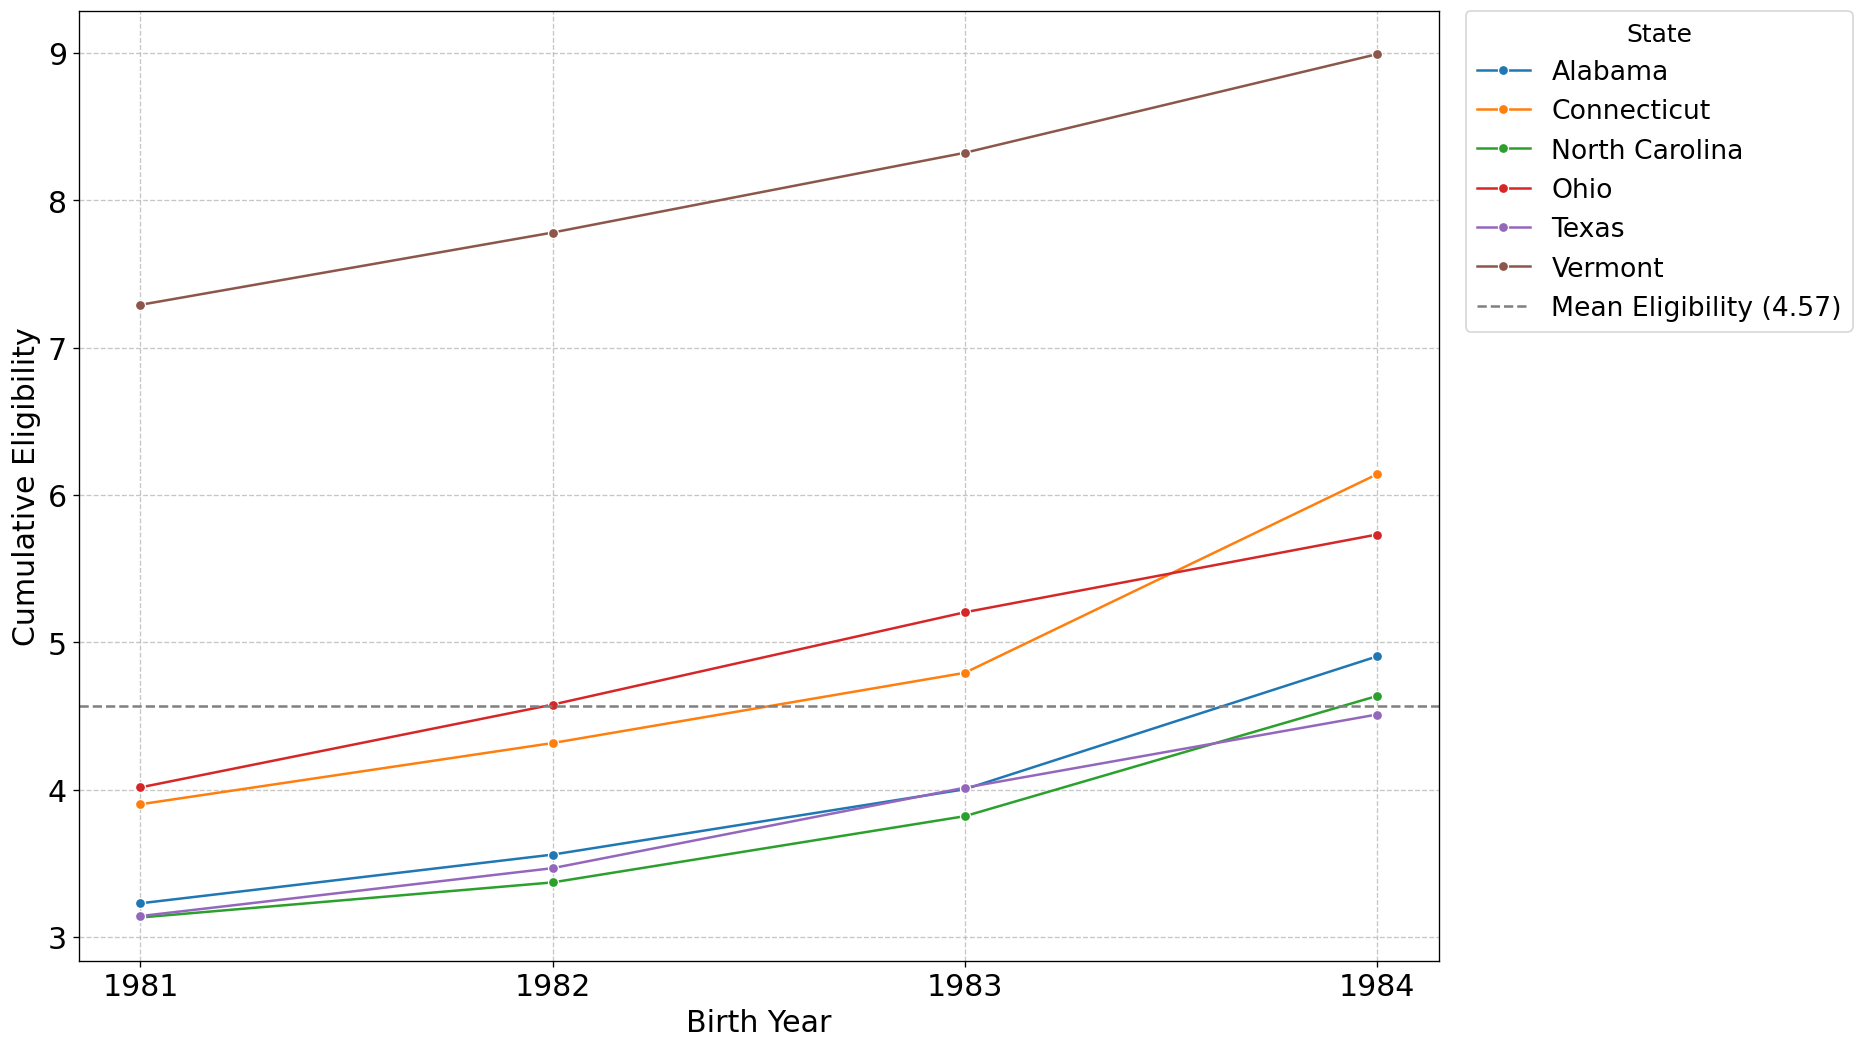

In [ ]:
# Define FIPS codes for selected states
state_fips_map = {
    'Alabama': 1,
    'Connecticut': 9,
    'Ohio': 39,
    'North Carolina': 37,
    'Texas': 48,
    'Vermont': 50
}

selected_fips = list(state_fips_map.values())

# Filter the aggregated data for the selected states and create a copy to avoid SettingWithCopyWarning
df_selected_states = df_aggregated_for_plots[df_aggregated_for_plots['STATEFIP'].isin(selected_fips)].copy()

# Add state names for better labeling
def get_state_name(fips_code):
    for name, code in state_fips_map.items():
        if code == fips_code:
            return name
    return str(fips_code) # Return FIPS code as string if not found

df_selected_states['StateName'] = df_selected_states['STATEFIP'].apply(get_state_name)

plt.figure(figsize=(18, 9)) # Increased figure width and height for larger graph
sns.lineplot(
    data=df_selected_states,
    x='birth_year',
    y='cumulative_eligibility_to_date',
    hue='StateName',
    marker='o',
    palette='tab10' # Using a distinct color palette
)

# Add horizontal reference line at mean (4.57)
mean_eligibility = 4.57
plt.axhline(y=mean_eligibility, color='gray', linestyle='--', label=f'Mean Eligibility ({mean_eligibility})')

plt.xlabel('Birth Year', fontsize=18)
plt.ylabel('Cumulative Eligibility', fontsize=18)
plt.xticks(df_selected_states['birth_year'].unique().astype(int)) # Ensure integer ticks for years
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='State', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.,fontsize=16) # Move legend to the right side

plt.tight_layout(rect=[0, 0, 0.88, 1]) # Adjust layout to prevent legend from being cut off
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Load and prepare Crime Data ---
# Assuming '/content/drive/MyDrive/Colab Notebooks/Thesis/Data/[Final]_US_Crime_Rates_1999_2010.csv' contains 'brthyr', 'STATEFIP', 'population', and rate columns.
df_crime = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Thesis/Data/[Final]_US_Crime_Rates_1999_2010.csv')

print("Crime Data (df_crime) head:")
display(df_crime.head())
print("\nCrime Data (df_crime) info:")
df_crime.info()

# Filter for birth years 1981-1984, using 'brthyr'
df_crime_filtered = df_crime[df_crime['brthyr'].isin([1981, 1982, 1983, 1984])]

# Define rate columns for weighted mean calculation
rate_cols = ['Drug_Rate', 'Violent_Rate', 'Property_Rate', 'Financial_Rate']

# Calculate population-weighted mean for each rate column by birth year
def weighted_mean(df, value_col, weight_col):
    return (df[value_col] * df[weight_col]).sum() / df[weight_col].sum()

df_crime_agg = df_crime_filtered.groupby('brthyr').apply(lambda x: pd.Series({
    col: weighted_mean(x, col, 'Population') for col in rate_cols # Use 'Population' for weight
})).reset_index()

# Rename 'brthyr' to 'birth_year' for consistency with eligibility data
df_crime_agg = df_crime_agg.rename(columns={'brthyr': 'birth_year'})

print("\nAggregated Crime Data (df_crime_agg) head:")
display(df_crime_agg.head())

# Melt the aggregated crime data for easier plotting of multiple lines
df_crime_agg_melted = df_crime_agg.melt(
    id_vars=['birth_year'],
    value_vars=rate_cols,
    var_name='Crime_Type',
    value_name='Weighted_Rate'
)

# --- 2. Prepare Eligibility Data ---
df_eligibility_agg = df_aggregated_for_plots.groupby('birth_year')['cumulative_eligibility_to_date'].mean().reset_index()

print("\nAggregated Eligibility Data (df_eligibility_agg) head:")
display(df_eligibility_agg.head())

Crime Data (df_crime) head:


,fips,year,age,crime_count,brthyr,Age,State,Population,Drug_Rate,Financial_Rate,...,cumulative_eligibility,elig_0_5,elig_6_11,elig_12_18,trend_cohort,Childhood_Avg_Unemployment,economically_motivated_crimes,state_abb,childhood_avg_income,log(income)
0,1,2000,19,1594,1981,19,AL,67769,142.395491,57.400877,...,3.228658,1.000340,0.858396,1.369921,0,7.957895,235.210790,AL,10537,9.262648
1,1,2001,19,1741,1982,19,AL,65031,141.009672,66.122311,...,3.559218,0.963729,0.939953,1.655536,1,7.642105,267.718473,AL,10732,9.280985
2,1,2001,20,1686,1981,20,AL,68511,133.263272,87.285253,...,3.228658,1.000340,0.858396,1.369921,0,7.957895,246.091868,AL,10537,9.262648
3,1,2002,19,1758,1983,19,AL,64169,154.124266,55.946018,...,3.929335,0.927237,0.999889,2.002209,2,7.168421,273.964064,AL,10937,9.299907
4,1,2002,20,1655,1982,20,AL,65515,152.636801,69.449744,...,3.559218,0.963729,0.939953,1.655536,1,7.642105,252.613905,AL,10732,9.280985



Crime Data (df_crime) info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1198 entries, 0 to 1197
Data columns (total 23 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   fips                           1198 non-null   int64  
 1   year                           1198 non-null   int64  
 2   age                            1198 non-null   int64  
 3   crime_count                    1198 non-null   int64  
 4   brthyr                         1198 non-null   int64  
 5   Age                            1198 non-null   int64  
 6   State                          1198 non-null   object 
 7   Population                     1198 non-null   int64  
 8   Drug_Rate                      1198 non-null   float64
 9   Financial_Rate                 1198 non-null   float64
 10  Property_Rate                  1198 non-null   float64
 11  PublicOrder_Rate               1198 non-null   float64
 12  Violent_Rate       

/tmp/ipykernel_19935/1689619781.py:24: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_crime_agg = df_crime_filtered.groupby('brthyr').apply(lambda x: pd.Series({


,birth_year,Drug_Rate,Violent_Rate,Property_Rate,Financial_Rate
0,1981,175.651578,143.284245,157.059362,41.647986
1,1982,175.040773,140.373574,155.160984,38.934211
2,1983,175.887024,137.667753,154.998080,35.619068
3,1984,175.441945,136.348238,153.390756,32.424284



Aggregated Eligibility Data (df_eligibility_agg) head:


,birth_year,cumulative_eligibility_to_date
0,1981,3.789350
1,1982,4.234088
2,1983,4.865350
3,1984,5.611949


### Figure 4: Eligibility Rising, Crime Rates Falling Across Birth Cohorts

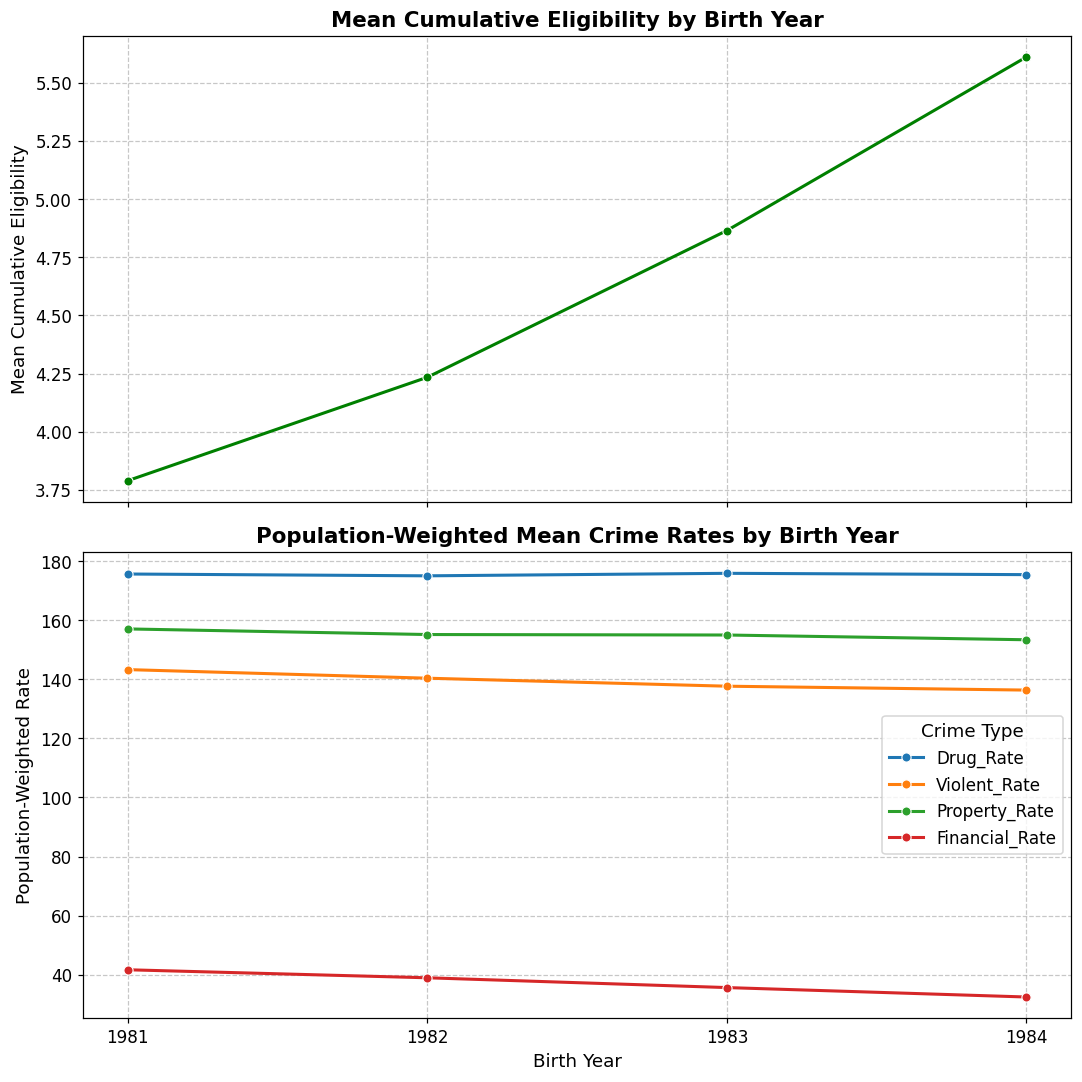

In [ ]:
# ================================================================
# NOTE: This exploratory two-panel figure is NOT in the current thesis.
# Kept here for reference only; no title/styling needed.
# ================================================================

# Create a two-panel figure with shared x-axis
fig, axes = plt.subplots(2, 1, sharex=True, figsize=(10, 10))

# --- Top Panel: Mean Cumulative Eligibility ---
sns.lineplot(
    data=df_eligibility_agg,
    x='birth_year',
    y='cumulative_eligibility_to_date',
    marker='o',
    ax=axes[0],
    color='green', # Distinct color for eligibility
    linewidth=2
)
axes[0].set_title('Mean Cumulative Eligibility by Birth Year')
axes[0].set_ylabel('Mean Cumulative Eligibility')
axes[0].grid(True, linestyle='--', alpha=0.7)

# --- Bottom Panel: Mean Crime Rates ---
sns.lineplot(
    data=df_crime_agg_melted,
    x='birth_year',
    y='Weighted_Rate',
    hue='Crime_Type',
    marker='o',
    ax=axes[1],
    palette='tab10', # Use a distinct palette for different crime types
    linewidth=2
)
axes[1].set_title('Population-Weighted Mean Crime Rates by Birth Year')
axes[1].set_xlabel('Birth Year')
axes[1].set_ylabel('Population-Weighted Rate')
axes[1].grid(True, linestyle='--', alpha=0.7)
axes[1].legend(title='Crime Type')

# Set x-axis ticks to show integer birth years
plt.xticks(df_eligibility_agg['birth_year'].unique().astype(int))

plt.tight_layout()
plt.show()

### Figure 3: Distribution of Cumulative Eligibility

This figure presents the distribution of cumulative eligibility across all 200 state × cohort cells (50 states × 4 cohorts). Overlapping kernel density estimates (KDEs) are used, colored by birth year, to show the full range, concentration, and the rightward shift in eligibility across cohorts.

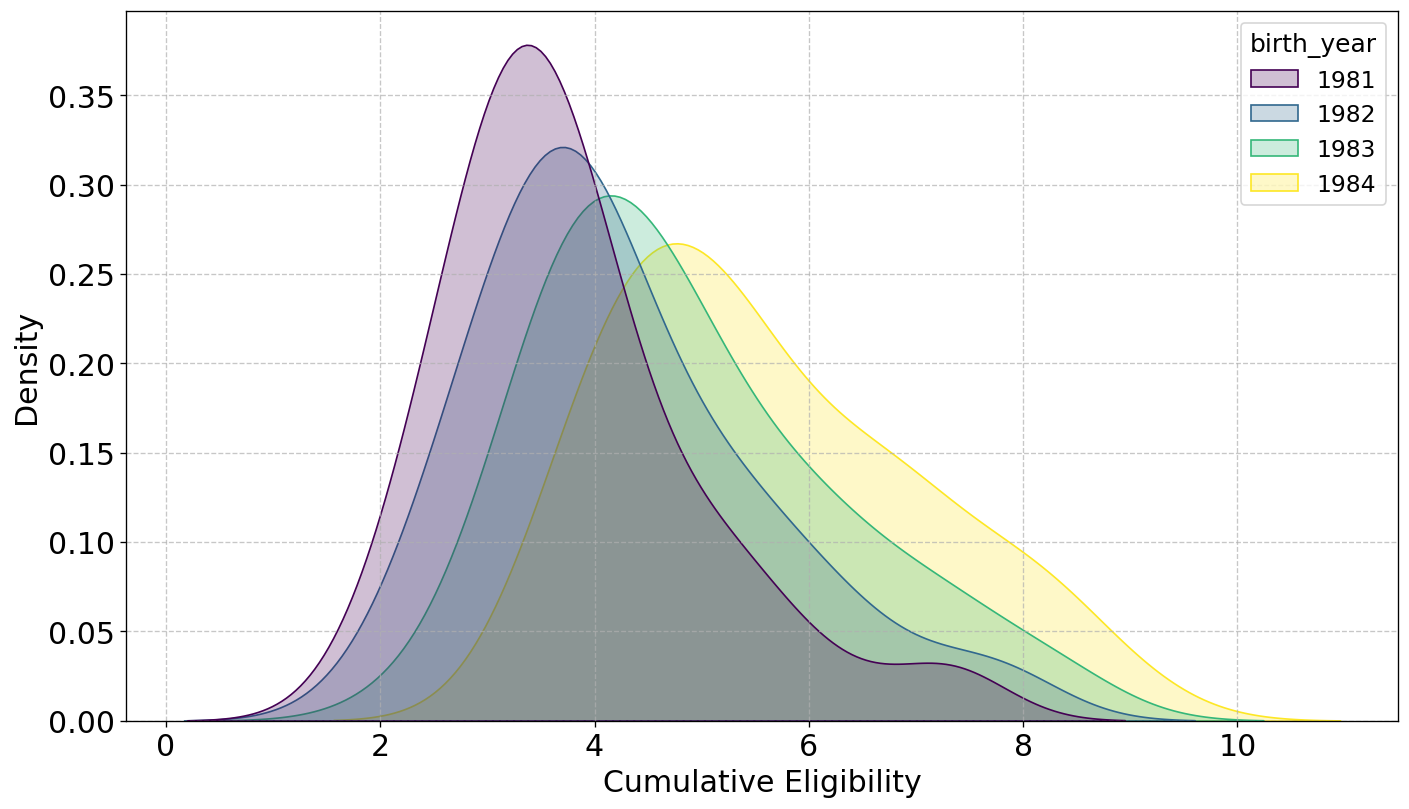

In [ ]:
plt.figure(figsize=(12, 7))

sns.kdeplot(
    data=df_aggregated_for_plots,
    x='cumulative_eligibility_to_date',
    hue='birth_year',
    fill=True,
    common_norm=False, # Each birth year density normalized independently
    palette='viridis' # Use a color palette to distinguish years
)

plt.xlabel('Cumulative Eligibility')
plt.ylabel('Density')
plt.grid(True, linestyle='--', alpha=0.7)
# plt.legend(title='Birth Year') # Removed to let seaborn handle the legend
plt.tight_layout()
plt.show()

### Figure 5: Crime Effects by Developmental Eligibility Window

Regression Data with CIs:


,Crime Type,Window,Coefficient,SE,ci_lower,ci_upper
0,Drug,cumulative,-13.32,6.55,-26.1580,-0.4820
1,Drug,elig_0_5,34.78,23.25,-10.7900,80.3500
2,Drug,elig_6_11,-5.18,4.63,-14.2548,3.8948
3,Drug,elig_12_18,-16.55,7.32,-30.8972,-2.2028
4,Violent,cumulative,-7.32,3.19,-13.5724,-1.0676


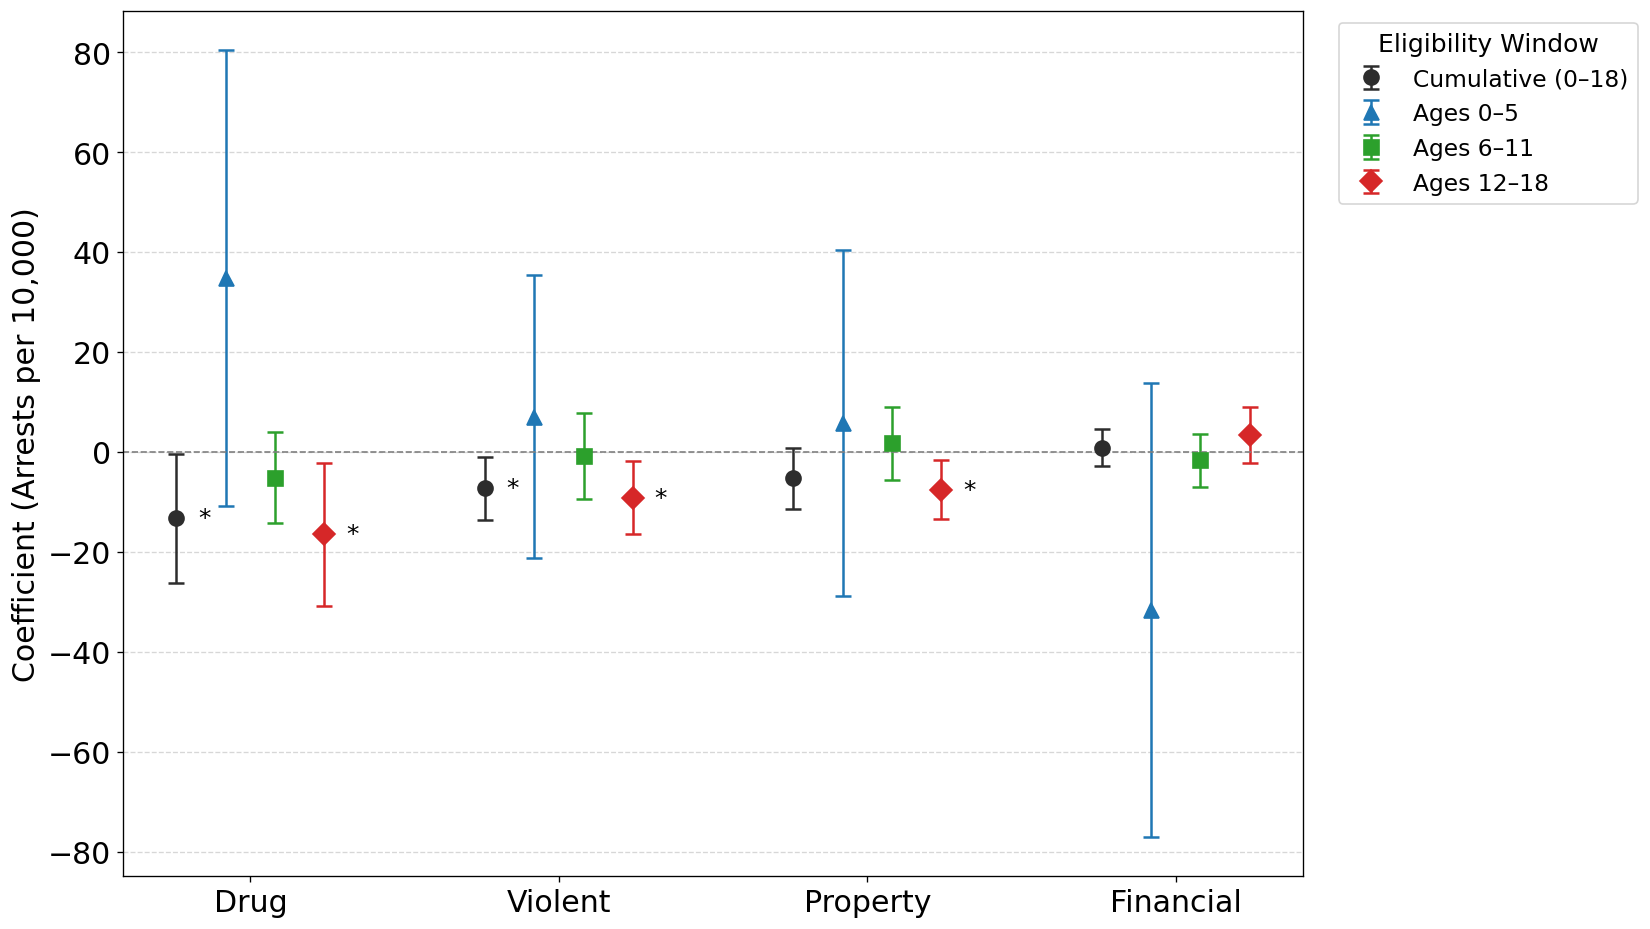

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Data from Table 1
data = {
    'Crime Type': [
        'Drug', 'Drug', 'Drug', 'Drug',
        'Violent', 'Violent', 'Violent', 'Violent',
        'Property', 'Property', 'Property', 'Property',
        'Financial', 'Financial', 'Financial', 'Financial'
    ],
    'Window': [
        'cumulative', 'elig_0_5', 'elig_6_11', 'elig_12_18',
        'cumulative', 'elig_0_5', 'elig_6_11', 'elig_12_18',
        'cumulative', 'elig_0_5', 'elig_6_11', 'elig_12_18',
        'cumulative', 'elig_0_5', 'elig_6_11', 'elig_12_18'
    ],
    'Coefficient': [
        -13.32, 34.78, -5.18, -16.55,
        -7.32, 7.06, -0.88, -9.20,
        -5.34, 5.81, 1.69, -7.62,
        0.86, -31.66, -1.73, 3.37
    ],
    'SE': [
        6.55, 23.25, 4.63, 7.32,
        3.19, 14.41, 4.40, 3.73,
        3.09, 17.68, 3.74, 3.01,
        1.93, 23.18, 2.73, 2.89
    ]
}

df_regression_plot = pd.DataFrame(data)

# Calculate 95% Confidence Intervals
df_regression_plot['ci_lower'] = df_regression_plot['Coefficient'] - 1.96 * df_regression_plot['SE']
df_regression_plot['ci_upper'] = df_regression_plot['Coefficient'] + 1.96 * df_regression_plot['SE']

print("Regression Data with CIs:")
display(df_regression_plot.head())

fig, ax = plt.subplots(figsize=(14, 8))

crime_types = ['Drug', 'Violent', 'Property', 'Financial']
windows = ['cumulative', 'elig_0_5', 'elig_6_11', 'elig_12_18']
offsets = [-0.24, -0.08, 0.08, 0.24]  # horizontal dodge

window_colors = {
    'cumulative': '#2d2d2d',
    'elig_0_5': '#1f77b4',
    'elig_6_11': '#2ca02c',
    'elig_12_18': '#d62728'
}

window_markers = {
    'cumulative': 'o',
    'elig_0_5': '^',
    'elig_6_11': 's',
    'elig_12_18': 'D'
}

window_labels = {
    'cumulative': 'Cumulative (0–18)',
    'elig_0_5': 'Ages 0–5',
    'elig_6_11': 'Ages 6–11',
    'elig_12_18': 'Ages 12–18'
}

plotted_labels = set() # To keep track of labels already plotted in the legend

for i, window in enumerate(windows):
    subset = df_regression_plot[df_regression_plot['Window'] == window]
    for j, row in subset.iterrows(): # Iterate row by row for each coefficient
        x_pos_crime_type = crime_types.index(row['Crime Type'])
        x_position = x_pos_crime_type + offsets[i]
        y_coeff = row['Coefficient']
        y_err_val = 1.96 * row['SE']

        # Check for significance (if CI does not cross zero)
        is_significant = (row['ci_lower'] > 0) or (row['ci_upper'] < 0)

        marker_style = window_markers[window]
        color_style = window_colors[window]

        label_for_legend = None
        if window_labels[window] not in plotted_labels:
            label_for_legend = window_labels[window]
            plotted_labels.add(window_labels[window])

        # Plot the error bar
        ax.errorbar(
            x_position,
            y_coeff,
            yerr=y_err_val,
            fmt=marker_style,
            color=color_style,
            markersize=9,
            capsize=5,
            capthick=1.5,
            linewidth=1.5,
            label=label_for_legend
        )

        # Add asterisk for significant points
        if is_significant:
            ax.text(x_position + 0.07, y_coeff, '*', color='black', fontsize=15, ha='left', va='center')


ax.axhline(0, color='grey', linestyle='--', linewidth=1)
ax.set_xticks(range(len(crime_types)))
ax.set_xticklabels(crime_types, fontsize=18)
ax.set_ylabel('Coefficient (Arrests per 10,000)', fontsize=18)
ax.legend(title='Eligibility Window', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=14)
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout(rect=[0, 0.08, 1, 1])

plt.tight_layout()
plt.show()

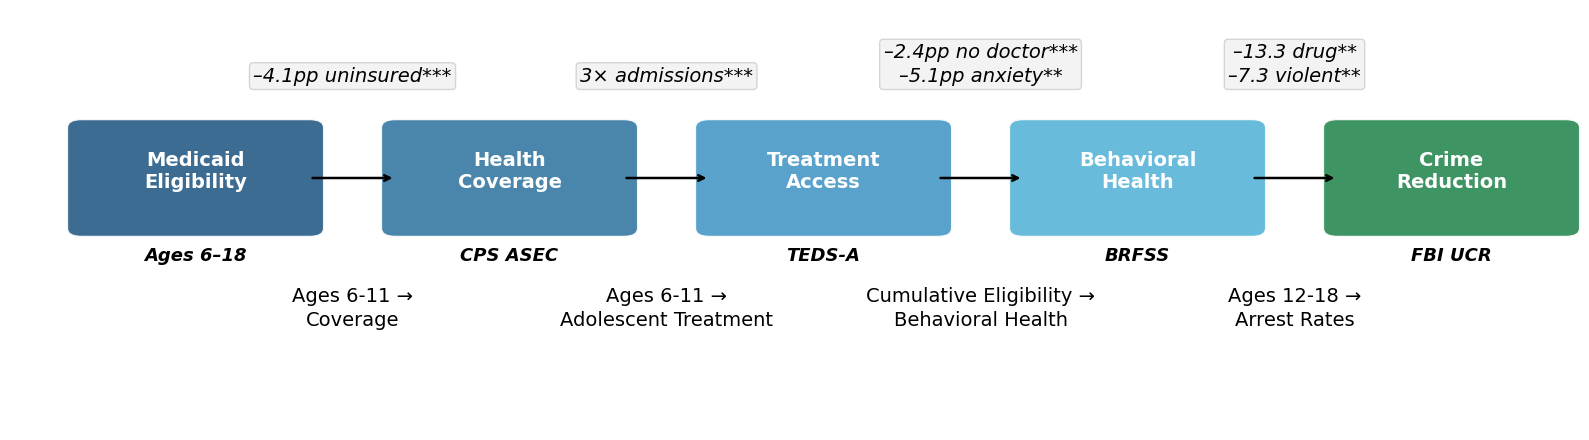

Saved: figure_causal_chain.pdf / .png


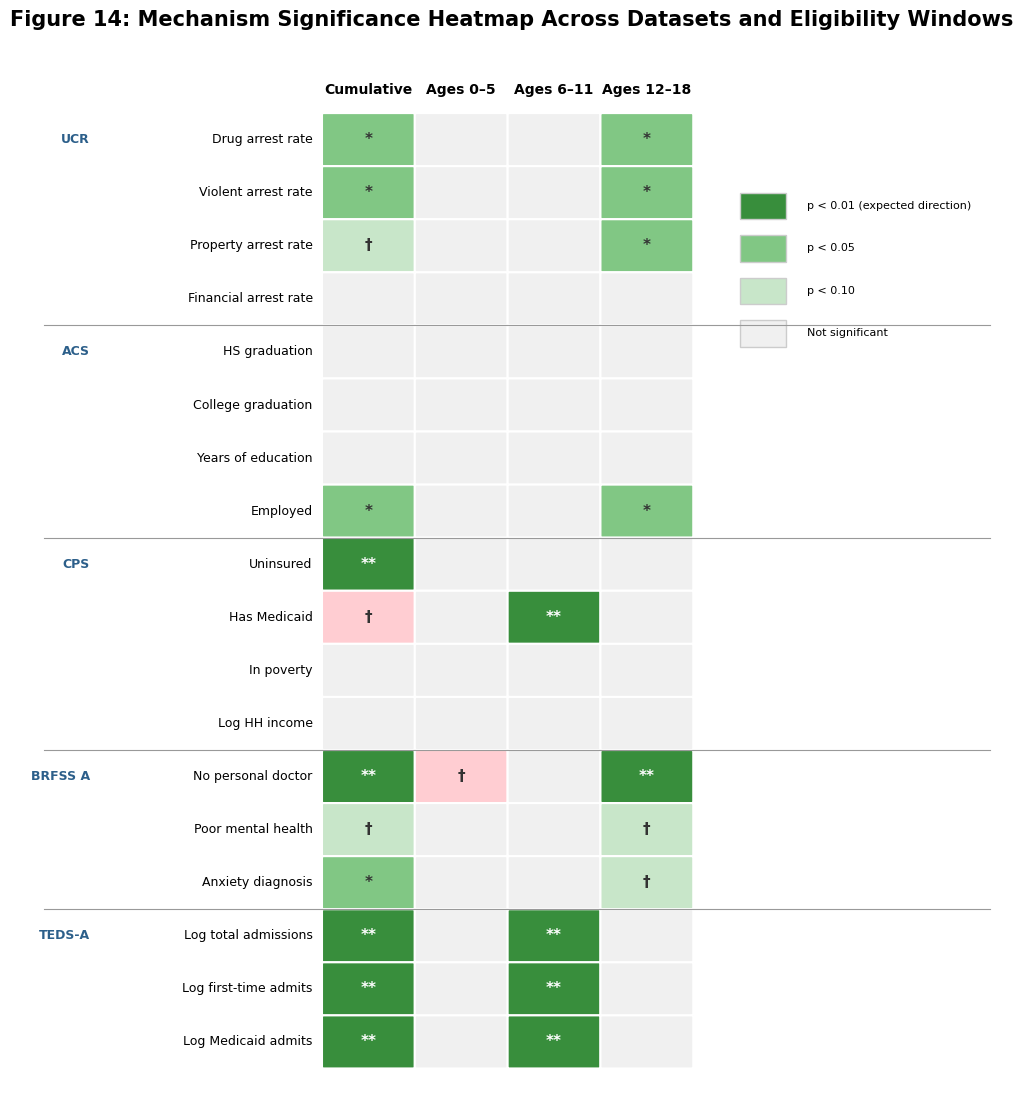

Saved: figure_mechanism_heatmap.pdf / .png


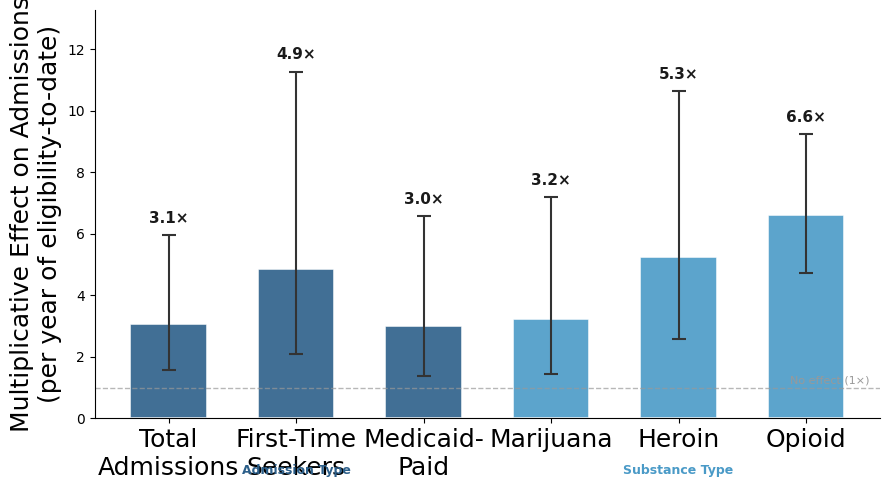

Saved: figure_tedsa_multipliers.pdf / .png


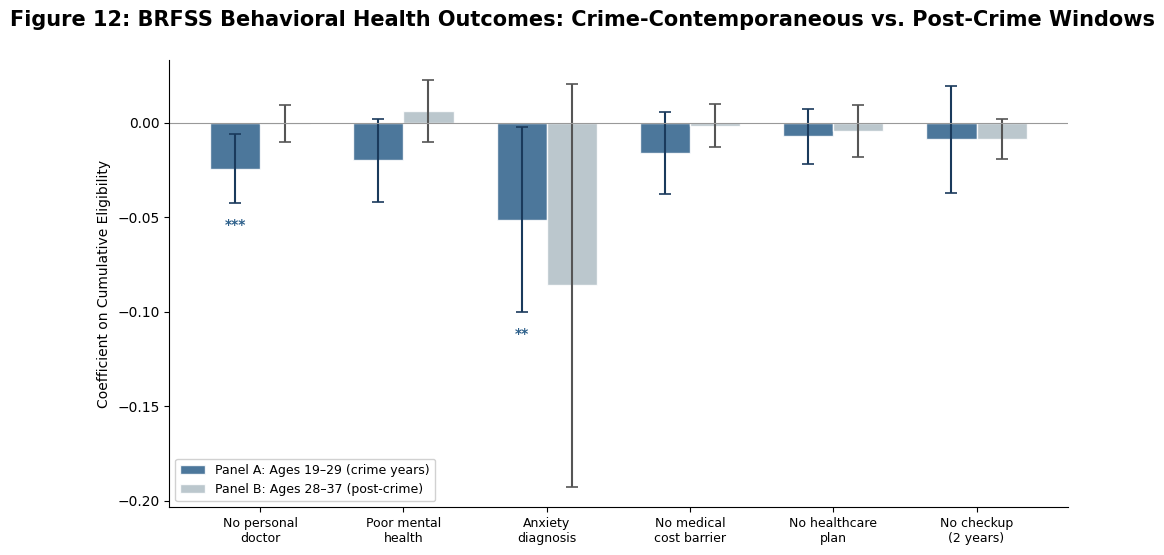

Saved: figure_brfss_panels.pdf / .png

All figures generated.


In [4]:
"""
Thesis Figures for "Insuring Against Crime"
Roman Modhera — Northwestern University, Spring 2026

Generates publication-quality figures from existing results.
Run in Google Colab or local Python environment.
"""

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
import numpy as np
from matplotlib.colors import LinearSegmentedColormap
from matplotlib import gridspec

# ============================================================
# FIGURE 5: Causal Chain Diagram — Section 6.1
# ============================================================

def figure_causal_chain():
    fig, ax = plt.subplots(figsize=(16, 4.5))
    ax.set_xlim(-0.5, 10.5)
    ax.set_ylim(-1.5, 3.5)
    ax.axis('off')

    # Box positions (x_center, y_center)
    boxes = [
        (0.8, 1.5, "Medicaid\nEligibility", "#2C5F8A", "Ages 6–18"),
        (3.0, 1.5, "Health\nCoverage",      "#3A7CA5", "CPS ASEC"),
        (5.2, 1.5, "Treatment\nAccess",     "#4A9AC7", "TEDS-A"),
        (7.4, 1.5, "Behavioral\nHealth",    "#5BB5D8", "BRFSS"),
        (9.6, 1.5, "Crime\nReduction",      "#2E8B57", "FBI UCR"),
    ]

    arrow_labels = [
        (1.9, 2.6, "–4.1pp uninsured***"),
        (4.1, 2.6, "3× admissions***"),
        (6.3, 2.6, "–2.4pp no doctor***\n–5.1pp anxiety**"),
        (8.5, 2.6, "–13.3 drug**\n–7.3 violent**"),
    ]

    window_labels = [
        (1.9, 0.2, "Ages 6-11 →\nCoverage"),
        (4.1, 0.2, "Ages 6-11 →\nAdolescent Treatment"),
        (6.3, 0.2, "Cumulative Eligibility →\nBehavioral Health"),
        (8.5, 0.2, "Ages 12-18 →\nArrest Rates"),
    ]

    box_width  = 1.6
    box_height = 1.2

    for x, y, label, color, dataset in boxes:
        rect = mpatches.FancyBboxPatch(
            (x - box_width/2, y - box_height/2), box_width, box_height,
            boxstyle="round,pad=0.1", facecolor=color, edgecolor='white',
            linewidth=1.5, alpha=0.92
        )
        ax.add_patch(rect)
        # Box title — stays white on the colored box
        ax.text(x, y + 0.08, label, ha='center', va='center',
                fontsize=14, fontweight='bold', color='white',
                linespacing=1.2)
        # Dataset subtitle — bigger, black, bold
        ax.text(x, y - box_height/2 - 0.22, dataset, ha='center', va='top',
                fontsize=13, fontstyle='italic', fontweight='bold',
                color='black')

    # Arrows between boxes
    arrow_style = dict(arrowstyle='->', color='black', lw=1.8,
                       connectionstyle='arc3,rad=0')
    for i in range(4):
        x_start = boxes[i][0] + box_width/2
        x_end   = boxes[i+1][0] - box_width/2
        ax.annotate('', xy=(x_end, 1.5), xytext=(x_start, 1.5),
                    arrowprops=arrow_style)

    # Evidence annotations above — black
    for x, y, label in arrow_labels:
        ax.text(x, y, label, ha='center', va='bottom',
                fontsize=14, color='black', fontstyle='italic',
                linespacing=1.3,
                bbox=dict(boxstyle='round,pad=0.2', facecolor='#f0f0f0',
                          edgecolor='#cccccc', alpha=0.8))

    # Window annotations below — black
    for x, y, label in window_labels:
        ax.text(x, y, label, ha='center', va='top',
                fontsize=14, color='black', linespacing=1.3)

    plt.tight_layout()
    plt.savefig('figure_causal_chain.pdf', bbox_inches='tight', dpi=300)
    plt.savefig('figure_causal_chain.png', bbox_inches='tight', dpi=300)
    plt.show()
    print("Saved: figure_causal_chain.pdf / .png")


# ============================================================
# FIGURE B: Mechanism Scorecard Heatmap
# Place in Section 6.1 or as an appendix summary
# ============================================================

def figure_mechanism_heatmap():
    fig, ax = plt.subplots(figsize=(10, 11))

    # Outcomes grouped by dataset, with coefficients for each window
    # Format: (label, dataset_group, [cumulative, elig_0_5, elig_6_11, elig_12_18], [sig levels])
    # sig: 0=null, 1=p<0.10, 2=p<0.05, 3=p<0.01

    data = [
        # Crime outcomes
        ("Drug arrest rate",         "UCR",      [-13.32, 34.78, -5.18, -16.55], [2, 0, 0, 2]),
        ("Violent arrest rate",      "UCR",      [-7.32, 7.06, -0.88, -9.20],   [2, 0, 0, 2]),
        ("Property arrest rate",     "UCR",      [-5.34, 5.81, 1.69, -7.62],    [1, 0, 0, 2]),
        ("Financial arrest rate",    "UCR",      [0.86, -31.66, -1.73, 3.37],   [0, 0, 0, 0]),
        # Education outcomes
        ("HS graduation",            "ACS",      [-0.0017, 0.0006, -0.0015, -0.0016], [0, 0, 0, 0]),
        ("College graduation",       "ACS",      [0.0017, 0.0025, -0.0003, 0.0021],  [0, 0, 0, 0]),
        ("Years of education",       "ACS",      [-0.0088, 0.0353, 0.0008, -0.0128], [0, 0, 0, 0]),
        ("Employed",                 "ACS",      [0.0054, 0.0049, -0.0003, 0.0065], [2, 0, 0, 2]),
        # Financial stress
        ("Uninsured",                "CPS",      [-0.041, 0, 0, 0],    [3, 0, 0, 0]),  # cum-to-date only
        ("Has Medicaid",             "CPS",      [-0.007, -0.007, 0.023, -0.005], [1, 0, 3, 0]),
        ("In poverty",               "CPS",      [0.002, -0.026, 0.007, 0.002],   [0, 0, 0, 0]),
        ("Log HH income",            "CPS",      [-0.015, 0.010, -0.019, 0.001], [0, 0, 0, 0]),
        # Behavioral health
        ("No personal doctor",       "BRFSS A",  [-0.0244, 0.0652, -0.0068, -0.0309], [3, 1, 0, 3]),
        ("Poor mental health",       "BRFSS A",  [-0.0200, 0.0149, -0.0098, -0.0209], [1, 0, 0, 1]),
        ("Anxiety diagnosis",        "BRFSS A",  [-0.0513, -0.1210, 0.0076, -0.0433], [2, 0, 0, 1]),
        # Treatment access
        ("Log total admissions",     "TEDS-A",   [1.12, 0, 2.18, 0],   [3, 0, 3, 0]),  # cum-to-date and elig_6_11
        ("Log first-time admits",    "TEDS-A",   [1.58, 0, 1.86, 0],   [3, 0, 3, 0]),
        ("Log Medicaid admits",      "TEDS-A",   [1.10, 0, 1.93, 0],   [3, 0, 3, 0]),
    ]

    n_rows = len(data)
    n_cols = 4
    windows = ["Cumulative", "Ages 0–5", "Ages 6–11", "Ages 12–18"]

    # Build significance matrix for coloring
    sig_matrix = np.zeros((n_rows, n_cols))
    coef_matrix = np.zeros((n_rows, n_cols))
    for i, (label, group, coefs, sigs) in enumerate(data):
        for j in range(4):
            sig_matrix[i, j] = sigs[j]
            coef_matrix[i, j] = coefs[j]

    # Color scheme: significance * sign
    # Green = significant negative (crime-reducing / health-improving)
    # Red = significant positive (unexpected direction)
    # Gray = null
    colors = np.full((n_rows, n_cols), '#F5F5F5')  # default light gray

    for i in range(n_rows):
        for j in range(n_cols):
            sig = sig_matrix[i, j]
            coef = coef_matrix[i, j]
            label = data[i][0]

            # For most outcomes, negative = good (less crime, less uninsured, etc.)
            # Exceptions: "Has Medicaid", "Employed", log admissions (positive = good)
            positive_is_good = label in ["Has Medicaid", "Employed",
                                          "Log total admissions", "Log first-time admits",
                                          "Log Medicaid admits"]

            if sig == 0:
                colors[i, j] = '#F0F0F0'
            elif sig == 1:
                if (coef < 0 and not positive_is_good) or (coef > 0 and positive_is_good):
                    colors[i, j] = '#C8E6C9'  # light green
                else:
                    colors[i, j] = '#FFCDD2'  # light red
            elif sig == 2:
                if (coef < 0 and not positive_is_good) or (coef > 0 and positive_is_good):
                    colors[i, j] = '#81C784'  # medium green
                else:
                    colors[i, j] = '#EF9A9A'  # medium red
            elif sig == 3:
                if (coef < 0 and not positive_is_good) or (coef > 0 and positive_is_good):
                    colors[i, j] = '#388E3C'  # dark green
                else:
                    colors[i, j] = '#E53935'  # dark red

    # Draw the heatmap
    for i in range(n_rows):
        for j in range(n_cols):
            rect = mpatches.FancyBboxPatch(
                (j + 0.02, n_rows - i - 1 + 0.02), 0.96, 0.96,
                boxstyle="round,pad=0.02", facecolor=colors[i, j],
                edgecolor='white', linewidth=1.5
            )
            ax.add_patch(rect)

            # Add significance stars
            sig = sig_matrix[i, j]
            if sig > 0:
                stars = {1: '†', 2: '*', 3: '**'}[int(sig)]
                text_color = 'white' if sig == 3 else '#333333'
                ax.text(j + 0.5, n_rows - i - 0.5, stars,
                        ha='center', va='center', fontsize=11,
                        fontweight='bold', color=text_color)

    # Row labels
    current_group = None
    for i, (label, group, _, _) in enumerate(data):
        y = n_rows - i - 0.5
        ax.text(-0.1, y, label, ha='right', va='center', fontsize=9)
        # Group separators
        if group != current_group:
            if current_group is not None:
                ax.axhline(y=n_rows - i, color='#999999', linewidth=0.8,
                          xmin=-0.02, xmax=1.02, clip_on=False)
            ax.text(-2.5, y, group, ha='right', va='center', fontsize=9,
                    fontweight='bold', color='#2C5F8A')
            current_group = group

    # Column labels
    for j, window in enumerate(windows):
        ax.text(j + 0.5, n_rows + 0.3, window, ha='center', va='bottom',
                fontsize=10, fontweight='bold')

    # Legend
    legend_items = [
        ('#388E3C', '  p < 0.01 (expected direction)'),
        ('#81C784', '  p < 0.05'),
        ('#C8E6C9', '  p < 0.10'),
        ('#F0F0F0', '  Not significant'),
    ]
    for k, (color, desc) in enumerate(legend_items):
        ax.add_patch(mpatches.Rectangle((n_cols + 0.5, n_rows - 2 - k * 0.8),
                                         0.5, 0.5, facecolor=color, edgecolor='#cccccc'))
        ax.text(n_cols + 1.15, n_rows - 1.75 - k * 0.8, desc,
                va='center', fontsize=8)

    ax.set_xlim(-2.8, n_cols + 3)
    ax.set_ylim(-0.5, n_rows + 1)
    ax.axis('off')



    fig.suptitle('Figure 14: Mechanism Significance Heatmap Across Datasets and Eligibility Windows',
                 fontsize=15, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.savefig('figure_mechanism_heatmap.pdf', bbox_inches='tight', dpi=300)
    plt.savefig('figure_mechanism_heatmap.png', bbox_inches='tight', dpi=300)
    plt.show()
    print("Saved: figure_mechanism_heatmap.pdf / .png")


# ============================================================
# FIGURE C: TEDS-A Exponentiated Multipliers
# Place in Section 4.7.3
# ============================================================

def figure_tedsa_multipliers():
    fig, ax = plt.subplots(figsize=(9, 5))

    outcomes = [
        'Total\nAdmissions', 'First-Time\nSeekers', 'Medicaid-\nPaid',
        'Marijuana', 'Heroin', 'Opioid'
    ]
    log_coefs = [1.12, 1.58, 1.10, 1.17, 1.66, 1.89]
    multipliers = [np.exp(c) for c in log_coefs]
    log_ses = [0.34, 0.43, 0.40, 0.41, 0.36, 0.17]

    # Confidence intervals (exponentiated)
    ci_low = [np.exp(c - 1.96*s) for c, s in zip(log_coefs, log_ses)]
    ci_high = [np.exp(c + 1.96*s) for c, s in zip(log_coefs, log_ses)]
    yerr_low = [m - l for m, l in zip(multipliers, ci_low)]
    yerr_high = [h - m for m, h in zip(multipliers, ci_high)]

    x = np.arange(len(outcomes))
    colors = ['#2C5F8A', '#2C5F8A', '#2C5F8A', '#4A9AC7', '#4A9AC7', '#4A9AC7']

    bars = ax.bar(x, multipliers, width=0.6, color=colors, edgecolor='white',
                  linewidth=1.2, alpha=0.9)
    ax.errorbar(x, multipliers, yerr=[yerr_low, yerr_high],
                fmt='none', ecolor='#333333', capsize=5, capthick=1.5, linewidth=1.5)

    # Reference line at 1× (no effect)
    ax.axhline(y=1, color='#999999', linestyle='--', linewidth=1, alpha=0.7)
    ax.text(len(outcomes) - 0.5, 1.15, 'No effect (1×)', fontsize=8,
            color='#999999', ha='right')

    # Value labels on bars
    for i, (bar, mult) in enumerate(zip(bars, multipliers)):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + yerr_high[i] + 0.3,
                f'{mult:.1f}×', ha='center', va='bottom', fontsize=11, fontweight='bold',
                color='#1a1a1a')

    ax.set_xticks(x)
    ax.set_xticklabels(outcomes, fontsize=18)
    ax.set_ylabel('Multiplicative Effect on Admissions\n(per year of eligibility-to-date)',
                  fontsize=18)


    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_ylim(0, max(ci_high) + 2)

    # Group labels
    ax.text(1, -1.8, 'Admission Type', ha='center', fontsize=9,
            fontweight='bold', color='#2C5F8A')
    ax.text(4, -1.8, 'Substance Type', ha='center', fontsize=9,
            fontweight='bold', color='#4A9AC7')


    plt.tight_layout()
    plt.savefig('figure_tedsa_multipliers.pdf', bbox_inches='tight', dpi=320)
    plt.savefig('figure_tedsa_multipliers.png', bbox_inches='tight', dpi=320)
    plt.show()
    print("Saved: figure_tedsa_multipliers.pdf / .png")


# ============================================================
# FIGURE D: BRFSS Cross-Panel Comparison
# Place in Section 4.6.3 or Section 6.1
# ============================================================

def figure_brfss_panels():
    fig, ax = plt.subplots(figsize=(10, 5.5))

    outcomes = [
        'No personal\ndoctor', 'Poor mental\nhealth', 'Anxiety\ndiagnosis',
        'No medical\ncost barrier', 'No healthcare\nplan', 'No checkup\n(2 years)'
    ]

    # Panel A coefficients (cumulative, ages 19-29)
    panel_a = [-0.0244, -0.0200, -0.0513, -0.0162, -0.0073, -0.0089]
    panel_a_se = [0.0093, 0.0112, 0.0249, 0.0111, 0.0074, 0.0145]
    panel_a_sig = [3, 1, 2, 0, 0, 0]  # significance level

    # Panel B coefficients (cumulative, ages 28-37)
    panel_b = [-0.0005, 0.0061, -0.0861, -0.0017, -0.0045, -0.0087]
    panel_b_se = [0.0049, 0.0083, 0.0544, 0.0058, 0.0070, 0.0053]
    panel_b_sig = [0, 0, 0, 0, 0, 1]

    x = np.arange(len(outcomes))
    width = 0.35

    # Panel A bars
    bars_a = ax.bar(x - width/2, panel_a, width, color='#2C5F8A', alpha=0.85,
                    label='Panel A: Ages 19–29 (crime years)', edgecolor='white')
    ax.errorbar(x - width/2, panel_a, yerr=[s*1.96 for s in panel_a_se],
                fmt='none', ecolor='#1a3a5c', capsize=4, capthick=1.2)

    # Panel B bars
    bars_b = ax.bar(x + width/2, panel_b, width, color='#B0BEC5', alpha=0.85,
                    label='Panel B: Ages 28–37 (post-crime)', edgecolor='white')
    ax.errorbar(x + width/2, panel_b, yerr=[s*1.96 for s in panel_b_se],
                fmt='none', ecolor='#555555', capsize=4, capthick=1.2)

    # Significance markers
    for i in range(len(outcomes)):
        if panel_a_sig[i] >= 2:
            stars = '**' if panel_a_sig[i] == 2 else '***'
            y_pos = panel_a[i] - panel_a_se[i]*1.96 - 0.008
            ax.text(x[i] - width/2, y_pos, stars, ha='center', va='top',
                    fontsize=10, fontweight='bold', color='#2C5F8A')

    ax.axhline(y=0, color='#999999', linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(outcomes, fontsize=9)
    ax.set_ylabel('Coefficient on Cumulative Eligibility', fontsize=10)
    ax.legend(fontsize=9, loc='lower left', framealpha=0.9)


    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)


    fig.suptitle('Figure 12: BRFSS Behavioral Health Outcomes: Crime-Contemporaneous vs. Post-Crime Windows',
                 fontsize=15, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.savefig('figure_brfss_panels.pdf', bbox_inches='tight', dpi=300)
    plt.savefig('figure_brfss_panels.png', bbox_inches='tight', dpi=300)
    plt.show()
    print("Saved: figure_brfss_panels.pdf / .png")


# ============================================================
# Run all
# ============================================================
if __name__ == "__main__":
    figure_causal_chain()
    figure_mechanism_heatmap()
    figure_tedsa_multipliers()
    figure_brfss_panels()
    print("\nAll figures generated.")

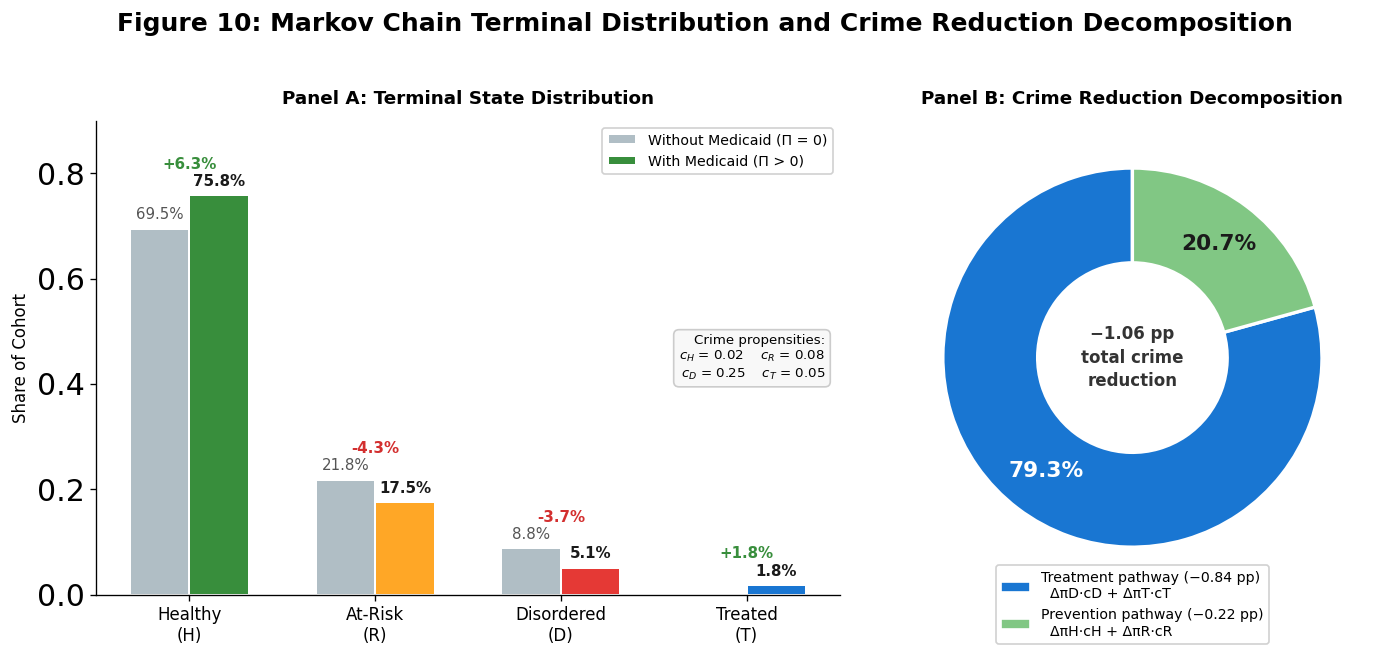

Saved: figure_markov_terminal.pdf / .png


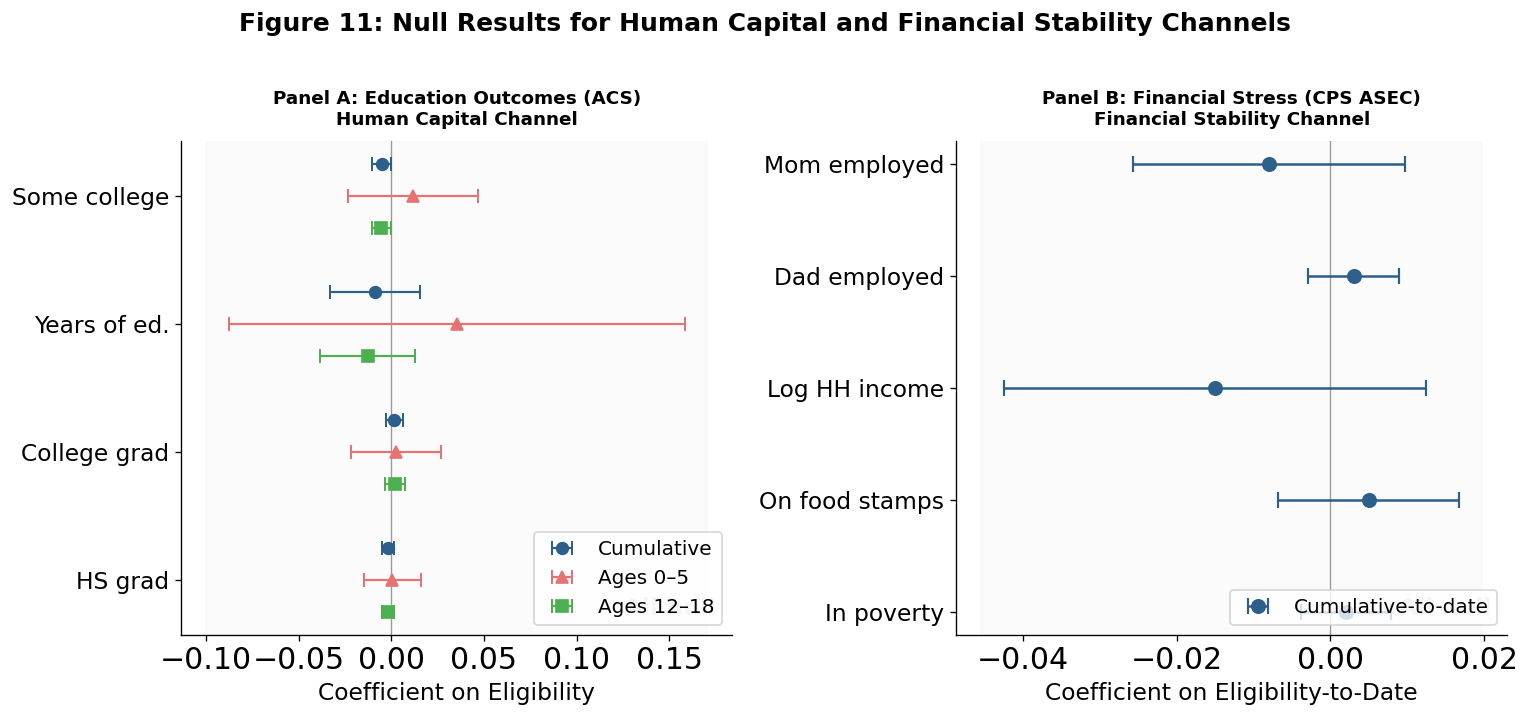

Saved: figure_null_results.pdf / .png


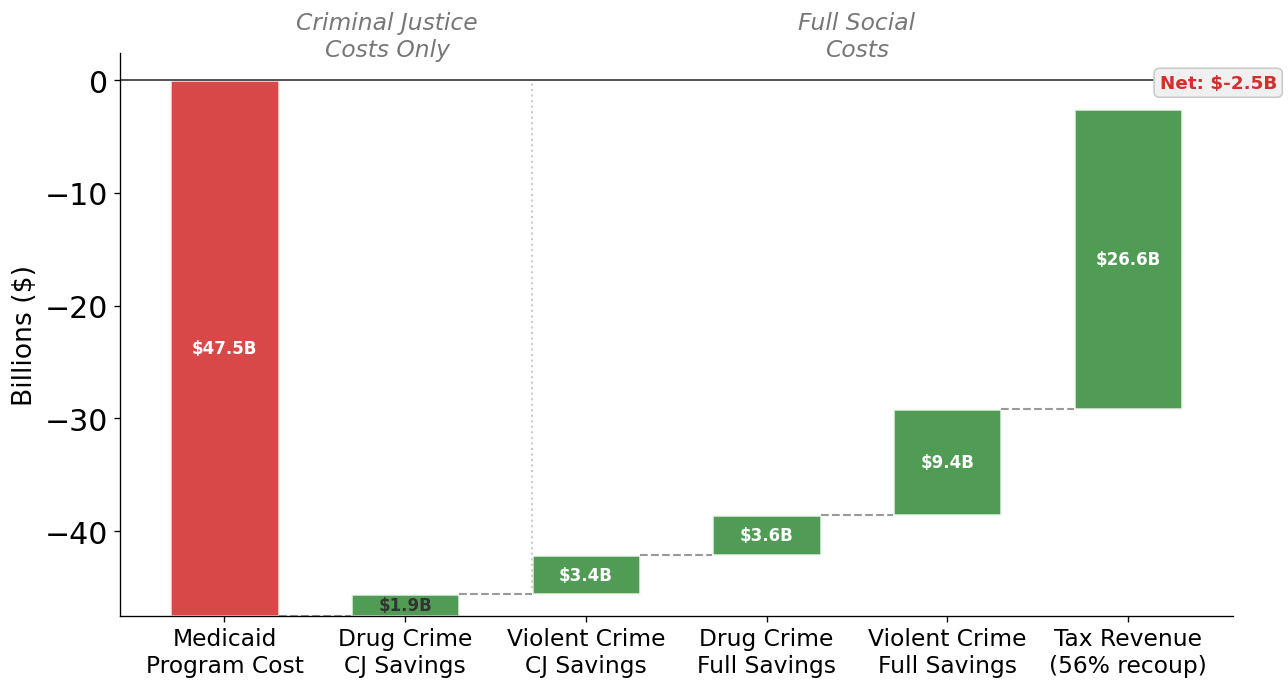

Saved: figure_cost_benefit.pdf / .png


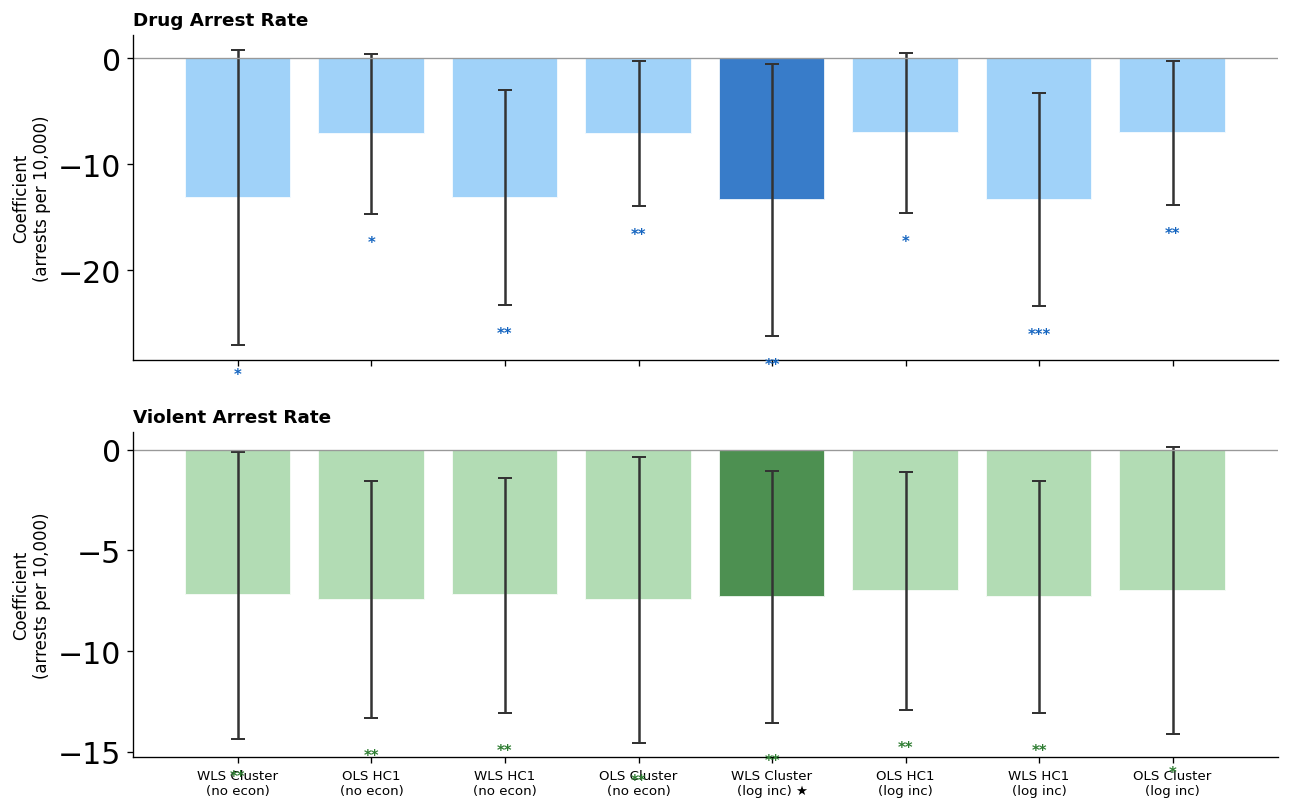

Saved: figure_crime_stability.pdf / .png


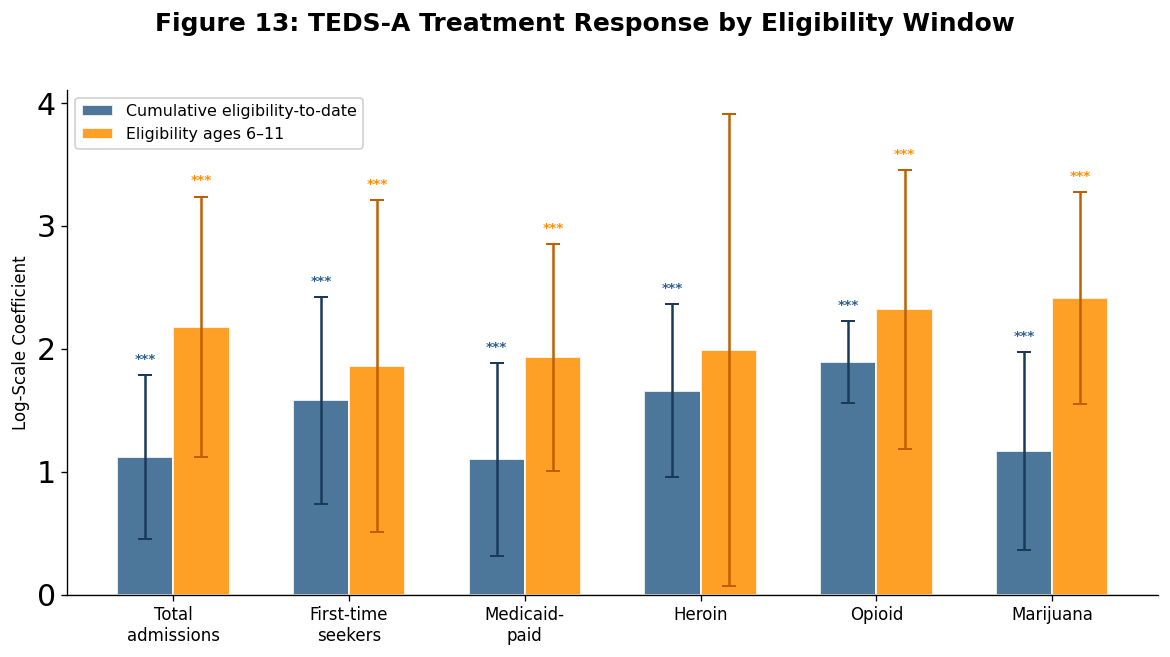

Saved: figure_tedsa_windows.pdf / .png


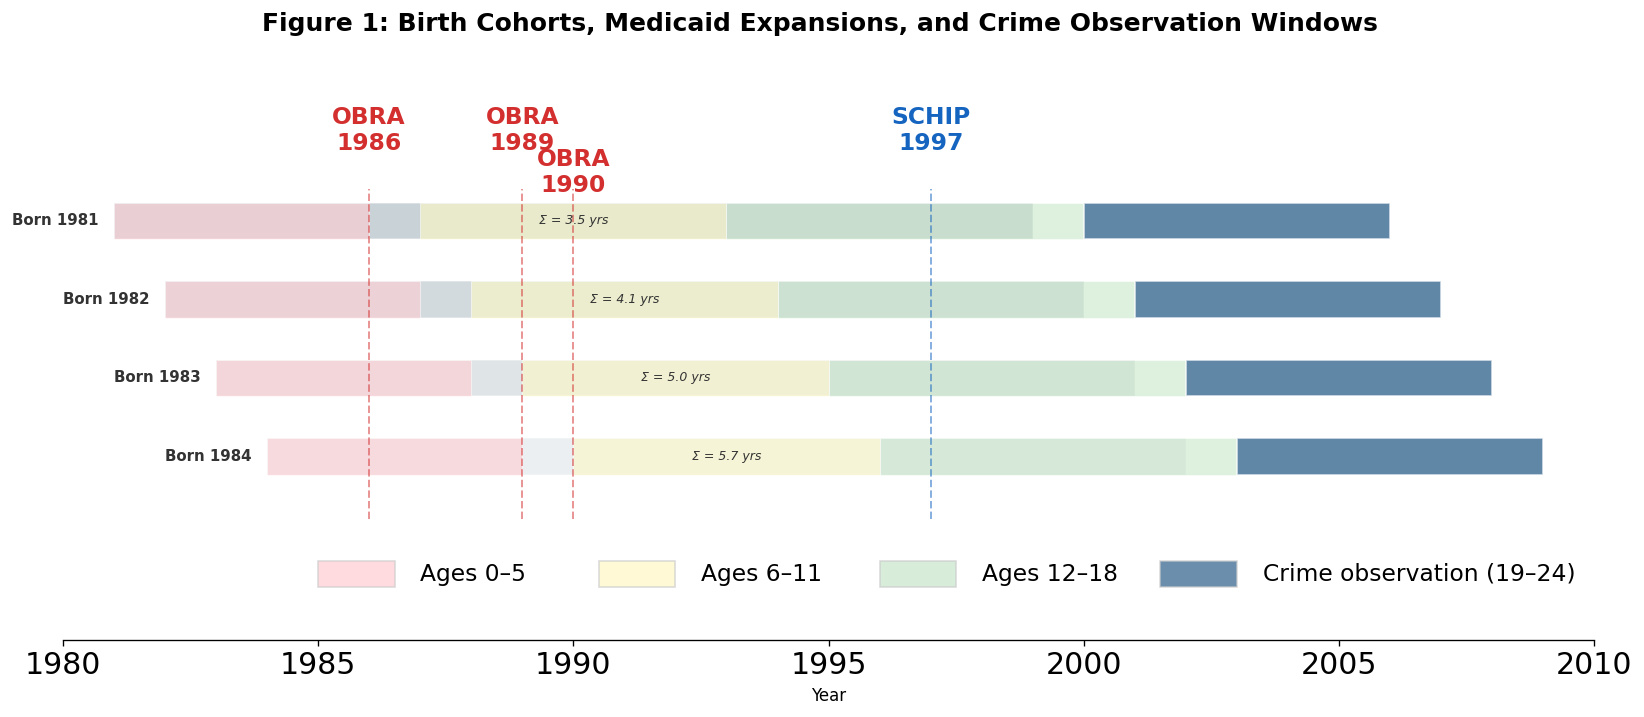

Saved: figure_timeline.pdf / .png

All additional figures generated.


In [ ]:
"""
Additional Thesis Figures — "Insuring Against Crime"
Roman Modhera — Northwestern University, Spring 2026

Figures 9–14, all from existing results (no new analysis).
"""

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
import numpy as np
from matplotlib import gridspec
from matplotlib.patches import FancyArrowPatch

# ============================================================
# FIGURE 9: Markov Chain Terminal Distribution
# Two-panel: stacked bars + crime decomposition pie
# Place in Section 3.2.5
# ============================================================

def figure_markov_terminal():
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5.5),
                                     gridspec_kw={'width_ratios': [1.4, 1]})

    # --- Panel A: Terminal State Distribution ---
    states = ['Healthy\n(H)', 'At-Risk\n(R)', 'Disordered\n(D)', 'Treated\n(T)']
    without = [0.695, 0.218, 0.088, 0.000]
    with_med = [0.758, 0.175, 0.051, 0.018]

    x = np.arange(len(states))
    width = 0.32

    colors_without = ['#78909C', '#78909C', '#D32F2F', '#78909C']
    colors_with = ['#388E3C', '#FFA726', '#E53935', '#1976D2']

    bars1 = ax1.bar(x - width/2, without, width, color='#B0BEC5', edgecolor='white',
                    linewidth=1.2, label='Without Medicaid (Π = 0)')
    bars2 = ax1.bar(x + width/2, with_med, width, color=colors_with, edgecolor='white',
                    linewidth=1.2, label='With Medicaid (Π > 0)')

    # Value labels
    for bar, val in zip(bars1, without):
        if val > 0.01:
            ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.012,
                    f'{val:.1%}', ha='center', va='bottom', fontsize=9, color='#555555')
    for bar, val in zip(bars2, with_med):
        if val > 0.005:
            ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.012,
                    f'{val:.1%}', ha='center', va='bottom', fontsize=9,
                    fontweight='bold', color='#1a1a1a')
        elif val == 0:
            ax1.text(bar.get_x() + bar.get_width()/2, 0.005,
                    '0%', ha='center', va='bottom', fontsize=8, color='#999999')

    # Arrows showing change
    for i in range(4):
        change = with_med[i] - without[i]
        if abs(change) > 0.005:
            sign = '+' if change > 0 else ''
            color = '#388E3C' if change > 0 else '#D32F2F'
            # Position arrow between bars
            y_pos = max(without[i], with_med[i]) + 0.045
            ax1.text(x[i], y_pos, f'{sign}{change:.1%}',
                    ha='center', va='bottom', fontsize=9, fontweight='bold',
                    color=color)

    ax1.set_xticks(x)
    ax1.set_xticklabels(states, fontsize=10)
    ax1.set_ylabel('Share of Cohort', fontsize=10)
    ax1.set_ylim(0, 0.90)
    ax1.legend(fontsize=8.5, loc='upper right', framealpha=0.9)
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    ax1.set_title('Panel A: Terminal State Distribution', fontsize=11,
                  fontweight='bold', pad=10)

    # Crime propensities annotation
    props_text = 'Crime propensities:\n$c_H$ = 0.02    $c_R$ = 0.08\n$c_D$ = 0.25    $c_T$ = 0.05'
    ax1.text(0.98, 0.55, props_text, transform=ax1.transAxes,
            fontsize=8, va='top', ha='right',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='#f8f8f8',
                      edgecolor='#cccccc'))

    # --- Panel B: Crime Reduction Decomposition ---
    treatment_pct = 79.3
    prevention_pct = 20.7

    wedges, texts, autotexts = ax2.pie(
        [treatment_pct, prevention_pct],
        labels=None,
        autopct='%1.1f%%',
        colors=['#1976D2', '#81C784'],
        startangle=90,
        wedgeprops=dict(width=0.5, edgecolor='white', linewidth=2),
        pctdistance=0.75,
        textprops={'fontsize': 13, 'fontweight': 'bold'}
    )
    autotexts[0].set_color('white')
    autotexts[1].set_color('#1a1a1a')

    # Center text
    ax2.text(0, 0, '−1.06 pp\ntotal crime\nreduction',
            ha='center', va='center', fontsize=10, fontweight='bold',
            color='#333333', linespacing=1.4)

    # Legend with explanations
    legend_elements = [
        mpatches.Patch(facecolor='#1976D2', edgecolor='white',
                       label='Treatment pathway (−0.84 pp)\n  ΔπD·cD + ΔπT·cT'),
        mpatches.Patch(facecolor='#81C784', edgecolor='white',
                       label='Prevention pathway (−0.22 pp)\n  ΔπH·cH + ΔπR·cR'),
    ]
    ax2.legend(handles=legend_elements, loc='lower center',
              fontsize=8.5, framealpha=0.9,
              bbox_to_anchor=(0.5, -0.12))

    ax2.set_title('Panel B: Crime Reduction Decomposition', fontsize=11,
                  fontweight='bold', pad=10)

    fig.suptitle('Figure 10: Markov Chain Terminal Distribution and Crime Reduction Decomposition',
                 fontsize=15, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.savefig('figure_markov_terminal.pdf', bbox_inches='tight', dpi=300)
    plt.savefig('figure_markov_terminal.png', bbox_inches='tight', dpi=300)
    plt.show()
    print("Saved: figure_markov_terminal.pdf / .png")


# ============================================================
# FIGURE 10: Null Results — Education & Financial Stress
# Coefficient plot showing everything is null
# Place in Section 6.1 (ruling out alternatives)
# ============================================================

def figure_null_results():
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6), sharey=False)

    # --- Panel A: Education (ACS) across all windows ---
    edu_outcomes = ['HS grad', 'College grad', 'Years of ed.', 'Some college']
    # Cumulative coefficients and SEs
    edu_cum_coef = [-0.0017, 0.0017, -0.0088, -0.0052]
    edu_cum_se = [0.0017, 0.0023, 0.0123, 0.0026]
    # elig_12_18 coefficients
    edu_1218_coef = [-0.0016, 0.0021, -0.0128, -0.0053]
    edu_1218_se = [0.0016, 0.0027, 0.0132, 0.0027]
    # elig_0_5 coefficients
    edu_05_coef = [0.0006, 0.0025, 0.0353, 0.0117]
    edu_05_se = [0.0079, 0.0124, 0.0627, 0.0179]

    y_pos = np.arange(len(edu_outcomes))
    offset = 0.25

    ax1.axvline(x=0, color='#999999', linewidth=0.8, linestyle='-')

    # Plot each window
    ax1.errorbar(edu_cum_coef, y_pos + offset, xerr=[s*1.96 for s in edu_cum_se],
                fmt='o', color='#2C5F8A', markersize=7, capsize=4, capthick=1.2,
                label='Cumulative', linewidth=1.3)
    ax1.errorbar(edu_05_coef, y_pos, xerr=[s*1.96 for s in edu_05_se],
                fmt='^', color='#E57373', markersize=7, capsize=4, capthick=1.2,
                label='Ages 0–5', linewidth=1.3)
    ax1.errorbar(edu_1218_coef, y_pos - offset, xerr=[s*1.96 for s in edu_1218_se],
                fmt='s', color='#4CAF50', markersize=7, capsize=4, capthick=1.2,
                label='Ages 12–18', linewidth=1.3)

    ax1.set_yticks(y_pos)
    ax1.set_yticklabels(edu_outcomes, fontsize=14)
    ax1.set_xlabel('Coefficient on Eligibility', fontsize=14)
    ax1.legend(fontsize=12, loc='lower right')
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    ax1.set_title('Panel A: Education Outcomes (ACS)\nHuman Capital Channel', fontsize=11,
                  fontweight='bold', pad=10)

    # Shade the null zone
    xlim = ax1.get_xlim()
    ax1.axvspan(xlim[0], xlim[1], alpha=0.04, color='#999999')
    ax1.text(0.97, 0.03, 'All null', transform=ax1.transAxes,
            fontsize=14, fontweight='bold', color='#B0BEC5',
            ha='right', va='bottom', alpha=0.7)

    # --- Panel B: Financial Stress (CPS) across windows ---
    fin_outcomes = ['In poverty', 'On food stamps', 'Log HH income',
                    'Dad employed', 'Mom employed']
    # Cumulative-to-date
    fin_cum_coef = [0.002, 0.005, -0.015, 0.003, -0.008]
    fin_cum_se = [0.003, 0.006, 0.014, 0.003, 0.009]

    y_pos2 = np.arange(len(fin_outcomes))

    ax2.axvline(x=0, color='#999999', linewidth=0.8, linestyle='-')

    ax2.errorbar(fin_cum_coef, y_pos2, xerr=[s*1.96 for s in fin_cum_se],
                fmt='o', color='#2C5F8A', markersize=8, capsize=5, capthick=1.3,
                linewidth=1.5, label='Cumulative-to-date')

    ax2.set_yticks(y_pos2)
    ax2.set_yticklabels(fin_outcomes, fontsize=14)
    ax2.set_xlabel('Coefficient on Eligibility-to-Date', fontsize=14)
    ax2.legend(fontsize=12, loc='lower right')
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    ax2.set_title('Panel B: Financial Stress (CPS ASEC)\nFinancial Stability Channel',
                  fontsize=11, fontweight='bold', pad=10)

    xlim2 = ax2.get_xlim()
    ax2.axvspan(xlim2[0], xlim2[1], alpha=0.04, color='#999999')
    ax2.text(0.97, 0.03, 'All null', transform=ax2.transAxes,
            fontsize=14, fontweight='bold', color='#B0BEC5',
            ha='right', va='bottom', alpha=0.7)



    fig.suptitle('Figure 11: Null Results for Human Capital and Financial Stability Channels',
                 fontsize=15, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.savefig('figure_null_results.pdf', bbox_inches='tight', dpi=300)
    plt.savefig('figure_null_results.png', bbox_inches='tight', dpi=300)
    plt.show()
    print("Saved: figure_null_results.pdf / .png")


# ============================================================
# FIGURE 11: Cost-Benefit Visualization
# Waterfall chart showing costs vs savings
# Place in Section 6.2
# ============================================================

def figure_cost_benefit():
    fig, ax = plt.subplots(figsize=(11, 6))

    # Data from Section 6.2
    categories = [
        'Medicaid\nProgram Cost',
        'Drug Crime\nCJ Savings',
        'Violent Crime\nCJ Savings',
        'Drug Crime\nFull Savings',
        'Violent Crime\nFull Savings',
        'Tax Revenue\n(56% recoup)'
    ]

    values = [-47.5, 1.91, 3.44, 3.62, 9.41, 26.6]  # billions
    # 56% of 47.5 = 26.6

    # Waterfall logic
    cumulative = [0]
    running = 0
    for v in values:
        cumulative.append(running + v)
        running += v

    colors = []
    for v in values:
        if v < 0:
            colors.append('#D32F2F')
        else:
            colors.append('#388E3C')

    # Draw bars
    bar_width = 0.6
    for i, (val, cat) in enumerate(zip(values, categories)):
        bottom = cumulative[i]
        if val < 0:
            bottom = cumulative[i] + val
            rect_val = abs(val)
        else:
            bottom = cumulative[i]
            rect_val = val

        bar = ax.bar(i, rect_val, bar_width, bottom=bottom, color=colors[i],
                     edgecolor='white', linewidth=1.5, alpha=0.88)

        # Value label
        label_y = cumulative[i] + val/2 if val < 0 else bottom + val/2
        ax.text(i, label_y, f'${abs(val):.1f}B',
                ha='center', va='center', fontsize=10, fontweight='bold',
                color='white' if abs(val) > 3 else '#333333')

    # Connect lines between bars
    for i in range(len(values) - 1):
        y_connect = cumulative[i+1]
        ax.plot([i + bar_width/2, i + 1 - bar_width/2], [y_connect, y_connect],
                color='#999999', linewidth=1.25, linestyle='--')

    # Net line
    net = sum(values)
    ax.axhline(y=0, color='#333333', linewidth=1)

    # Annotations for subtotals
    # CJ-only savings
    cj_total = 1.91 + 3.44


    # Full social savings
    full_total = 1.91 + 3.44 + 3.62 + 9.41
    # Not adding arrow to avoid clutter

    # Net annotation
    ax.text(5.5, net + 1.5, f'Net: ${net:+.1f}B',
            ha='center', va='bottom', fontsize=11, fontweight='bold',
            color='#D32F2F' if net < 0 else '#388E3C',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#f0f0f0',
                      edgecolor='#cccccc'))

    # Divider between CJ-only and full social
    ax.axvline(x=1.7, color='#cccccc', linewidth=1.25, linestyle=':',
               ymin=0.05, ymax=0.95)
    ax.text(0.9, ax.get_ylim()[1] * 0.92, 'Criminal Justice\nCosts Only',
            ha='center', fontsize=14, color='#777777', fontstyle='italic')
    ax.text(3.5, ax.get_ylim()[1] * 0.92, 'Full Social\nCosts',
            ha='center', fontsize=14, color='#777777', fontstyle='italic')

    ax.set_xticks(range(len(categories)))
    ax.set_xticklabels(categories, fontsize=14, rotation=0)
    ax.set_ylabel('Billions ($)', fontsize=16)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)


    plt.tight_layout()
    plt.savefig('figure_cost_benefit.pdf', bbox_inches='tight', dpi=300)
    plt.savefig('figure_cost_benefit.png', bbox_inches='tight', dpi=300)
    plt.show()
    print("Saved: figure_cost_benefit.pdf / .png")


# ============================================================
# FIGURE 12: Crime Coefficient Stability Across Specifications
# Shows all 8 specs for drug and violent crime
# Place in Appendix or Section 4.3.3
# ============================================================

def figure_crime_stability():
    # NOTE: Not in current thesis draft — kept for optional use.
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

    specs = [
        'WLS Cluster\n(no econ)',
        'OLS HC1\n(no econ)',
        'WLS HC1\n(no econ)',
        'OLS Cluster\n(no econ)',
        'WLS Cluster\n(log inc) ★',
        'OLS HC1\n(log inc)',
        'WLS HC1\n(log inc)',
        'OLS Cluster\n(log inc)',
    ]

    # Drug Rate — cumulative eligibility, all 8 specs (from Appendix Table A1)
    drug_coefs = [-13.14, -7.11, -13.14, -7.11, -13.32, -7.05, -13.32, -7.05]
    drug_ses =   [7.12,   3.86,  5.17,   3.49,  6.55,   3.86,  5.14,   3.45]

    # Violent Rate — cumulative eligibility
    viol_coefs = [-7.24, -7.44, -7.24, -7.44, -7.32, -7.00, -7.32, -7.00]
    viol_ses =   [3.63,  3.00,  2.97,  3.62,  3.19,  3.01,  2.94,  3.64]

    x = np.arange(len(specs))

    # --- Drug Rate ---
    colors_drug = ['#90CAF9'] * 4 + ['#1565C0'] + ['#90CAF9'] * 3
    ax1.bar(x, drug_coefs, color=colors_drug, edgecolor='white', linewidth=1.2, alpha=0.85)
    ax1.errorbar(x, drug_coefs, yerr=[s*1.96 for s in drug_ses],
                fmt='none', ecolor='#333333', capsize=4, capthick=1.2)
    ax1.axhline(y=0, color='#999999', linewidth=0.8)
    ax1.set_ylabel('Coefficient\n(arrests per 10,000)', fontsize=10)
    ax1.set_title('Drug Arrest Rate', fontsize=11, fontweight='bold', loc='left')
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)

    # Significance markers
    for i, (c, s) in enumerate(zip(drug_coefs, drug_ses)):
        p_approx = abs(c) / s
        if p_approx > 2.58:
            stars = '***'
        elif p_approx > 1.96:
            stars = '**'
        elif p_approx > 1.645:
            stars = '*'
        else:
            stars = ''
        if stars:
            ax1.text(i, c - s*1.96 - 2, stars, ha='center', va='top',
                    fontsize=9, fontweight='bold', color='#1565C0')

    # --- Violent Rate ---
    colors_viol = ['#A5D6A7'] * 4 + ['#2E7D32'] + ['#A5D6A7'] * 3
    ax2.bar(x, viol_coefs, color=colors_viol, edgecolor='white', linewidth=1.2, alpha=0.85)
    ax2.errorbar(x, viol_coefs, yerr=[s*1.96 for s in viol_ses],
                fmt='none', ecolor='#333333', capsize=4, capthick=1.2)
    ax2.axhline(y=0, color='#999999', linewidth=0.8)
    ax2.set_ylabel('Coefficient\n(arrests per 10,000)', fontsize=10)
    ax2.set_title('Violent Arrest Rate', fontsize=11, fontweight='bold', loc='left')
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)

    for i, (c, s) in enumerate(zip(viol_coefs, viol_ses)):
        p_approx = abs(c) / s
        if p_approx > 2.58:
            stars = '***'
        elif p_approx > 1.96:
            stars = '**'
        elif p_approx > 1.645:
            stars = '*'
        else:
            stars = ''
        if stars:
            ax2.text(i, c - s*1.96 - 1.5, stars, ha='center', va='top',
                    fontsize=9, fontweight='bold', color='#2E7D32')

    ax2.set_xticks(x)
    ax2.set_xticklabels(specs, fontsize=8, rotation=0)



    plt.tight_layout()
    plt.savefig('figure_crime_stability.pdf', bbox_inches='tight', dpi=300)
    plt.savefig('figure_crime_stability.png', bbox_inches='tight', dpi=300)
    plt.show()
    print("Saved: figure_crime_stability.pdf / .png")


# ============================================================
# FIGURE 13: TEDS-A Window Comparison
# elig_6_11 vs cumulative-to-date for treatment outcomes
# Place in Section 4.7.3 or Section 6.1
# ============================================================

def figure_tedsa_windows():
    fig, ax = plt.subplots(figsize=(10, 5.5))

    outcomes = [
        'Total\nadmissions', 'First-time\nseekers', 'Medicaid-\npaid',
        'Heroin', 'Opioid', 'Marijuana'
    ]

    # Cumulative eligibility-to-date coefficients (log scale)
    cum_coefs = [1.12, 1.58, 1.10, 1.66, 1.89, 1.17]
    cum_ses =   [0.34, 0.43, 0.40, 0.36, 0.17, 0.41]

    # elig_6_11 coefficients (log scale)
    e611_coefs = [2.18, 1.86, 1.93, 1.99, 2.32, 2.41]
    e611_ses =   [0.54, 0.69, 0.47, 0.98, 0.58, 0.44]

    x = np.arange(len(outcomes))
    width = 0.32

    bars1 = ax.bar(x - width/2, cum_coefs, width, color='#2C5F8A', alpha=0.85,
                   edgecolor='white', linewidth=1.2,
                   label='Cumulative eligibility-to-date')
    bars2 = ax.bar(x + width/2, e611_coefs, width, color='#FF8F00', alpha=0.85,
                   edgecolor='white', linewidth=1.2,
                   label='Eligibility ages 6–11')

    ax.errorbar(x - width/2, cum_coefs, yerr=[s*1.96 for s in cum_ses],
               fmt='none', ecolor='#1a3a5c', capsize=4, capthick=1.2)
    ax.errorbar(x + width/2, e611_coefs, yerr=[s*1.96 for s in e611_ses],
               fmt='none', ecolor='#BF6000', capsize=4, capthick=1.2)

    # Significance markers
    cum_sig =  ['***', '***', '***', '***', '***', '***']
    e611_sig = ['***', '***', '***', '',    '***', '***']

    for i in range(len(outcomes)):
        if cum_sig[i]:
            ax.text(x[i] - width/2, cum_coefs[i] + cum_ses[i]*1.96 + 0.1,
                   cum_sig[i], ha='center', fontsize=8, fontweight='bold', color='#2C5F8A')
        if e611_sig[i]:
            ax.text(x[i] + width/2, e611_coefs[i] + e611_ses[i]*1.96 + 0.1,
                   e611_sig[i], ha='center', fontsize=8, fontweight='bold', color='#FF8F00')

    ax.axhline(y=0, color='#999999', linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(outcomes, fontsize=10)
    ax.set_ylabel('Log-Scale Coefficient', fontsize=10)
    ax.legend(fontsize=9.5, loc='upper left', framealpha=0.9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)





    fig.suptitle('Figure 13: TEDS-A Treatment Response by Eligibility Window',
                 fontsize=15, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.savefig('figure_tedsa_windows.pdf', bbox_inches='tight', dpi=300)
    plt.savefig('figure_tedsa_windows.png', bbox_inches='tight', dpi=300)
    plt.show()
    print("Saved: figure_tedsa_windows.pdf / .png")


# ============================================================
# FIGURE 14: Legislative Timeline + Cohort Observation Map
# Shows when legislation happened, when cohorts were eligible,
# and when outcomes are observed
# Place in Section 4.1 or Introduction
# ============================================================

def figure_timeline():
    fig, ax = plt.subplots(figsize=(14, 6))
    ax.set_xlim(1980, 2010)
    ax.set_ylim(-2, 8.5)

    # --- Legislation markers (top) ---
    # (year, label, color, y_position) — y staggered so close-together labels don't overlap
    legislation = [
        (1986, 'OBRA\n1986', '#D32F2F', 8.2),
        (1989, 'OBRA\n1989', '#D32F2F', 8.2),
        (1990, 'OBRA\n1990', '#D32F2F', 7.4),   # staggered lower so it clears 1989
        (1997, 'SCHIP\n1997', '#1565C0', 8.2),
    ]

    for year, label, color, y_pos in legislation:
        # Dashed line terminates at ymax=0.78 so it sits above the legend row
        ax.axvline(x=year, color=color, linewidth=1.2, linestyle='--', alpha=0.5,
                   ymin=0.22, ymax=0.82)
        ax.text(year, y_pos, label, ha='center', va='top', fontsize=14,
                fontweight='bold', color=color)

    # --- Cohort bars ---
    cohorts = [
        (1981, 'Born 1981', '#78909C'),
        (1982, 'Born 1982', '#90A4AE'),
        (1983, 'Born 1983', '#B0BEC5'),
        (1984, 'Born 1984', '#CFD8DC'),
    ]

    bar_height = 0.7
    for i, (birth_year, label, color) in enumerate(cohorts):
        y_base = 6 - i * 1.5

        # Childhood eligibility period (birth to 18)
        ax.barh(y_base, 18, left=birth_year, height=bar_height,
                color=color, alpha=0.4, edgecolor='white')

        # Developmental windows
        ax.barh(y_base, 5, left=birth_year, height=bar_height,
                color='#FFCDD2', alpha=0.6, edgecolor='white', linewidth=0.5)
        ax.barh(y_base, 6, left=birth_year + 6, height=bar_height,
                color='#FFF9C4', alpha=0.6, edgecolor='white', linewidth=0.5)
        ax.barh(y_base, 7, left=birth_year + 12, height=bar_height,
                color='#C8E6C9', alpha=0.6, edgecolor='white', linewidth=0.5)

        # Crime observation period (ages 19-24)
        ax.barh(y_base, 6, left=birth_year + 19, height=bar_height,
                color='#2C5F8A', alpha=0.75, edgecolor='white', linewidth=1)

        # Label
        ax.text(birth_year - 0.3, y_base, label, ha='right', va='center',
                fontsize=9, fontweight='bold', color='#333333')

        # Eligibility value
        elig_values = {1981: 3.49, 1982: 4.08, 1983: 4.96, 1984: 5.74}
        ax.text(birth_year + 9, y_base, f'Σ = {elig_values[birth_year]:.1f} yrs',
                ha='center', va='center', fontsize=7.5, color='#333333', fontstyle='italic')

    # Legend for developmental windows
    legend_y = -0.8
    legend_items = [
        ('#FFCDD2', 'Ages 0–5'),
        ('#FFF9C4', 'Ages 6–11'),
        ('#C8E6C9', 'Ages 12–18'),
        ('#2C5F8A', 'Crime observation (19–24)'),
    ]
    for j, (color, desc) in enumerate(legend_items):
        x_pos = 1985 + j * 5.5
        ax.add_patch(mpatches.Rectangle((x_pos, legend_y - 0.2), 1.5, 0.5,
                                        facecolor=color, edgecolor='#cccccc',
                                        alpha=0.7))
        ax.text(x_pos + 2, legend_y + 0.05, desc, va='center', fontsize=14)

    ax.set_xlabel('Year', fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.set_yticks([])

    fig.suptitle('Figure 1: Birth Cohorts, Medicaid Expansions, and Crime Observation Windows',
                 fontsize=15, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.savefig('figure_timeline.pdf', bbox_inches='tight', dpi=300)
    plt.savefig('figure_timeline.png', bbox_inches='tight', dpi=300)
    plt.show()
    print("Saved: figure_timeline.pdf / .png")

# ============================================================
# Run all
# ============================================================
if __name__ == "__main__":
    figure_markov_terminal()
    figure_null_results()
    figure_cost_benefit()
    figure_crime_stability()
    figure_tedsa_windows()
    figure_timeline()
    print("\nAll additional figures generated.")

### Figure 6: Behavioral Health Markov Chain (With / Without Medicaid)
Placed in Section 6.2. Structural diagram of the four-state behavioral health chain, calibrated with parameters from Kessler et al. (2005), Costello et al. (2003), Fleury et al. (2016), and SAMHSA (2024).


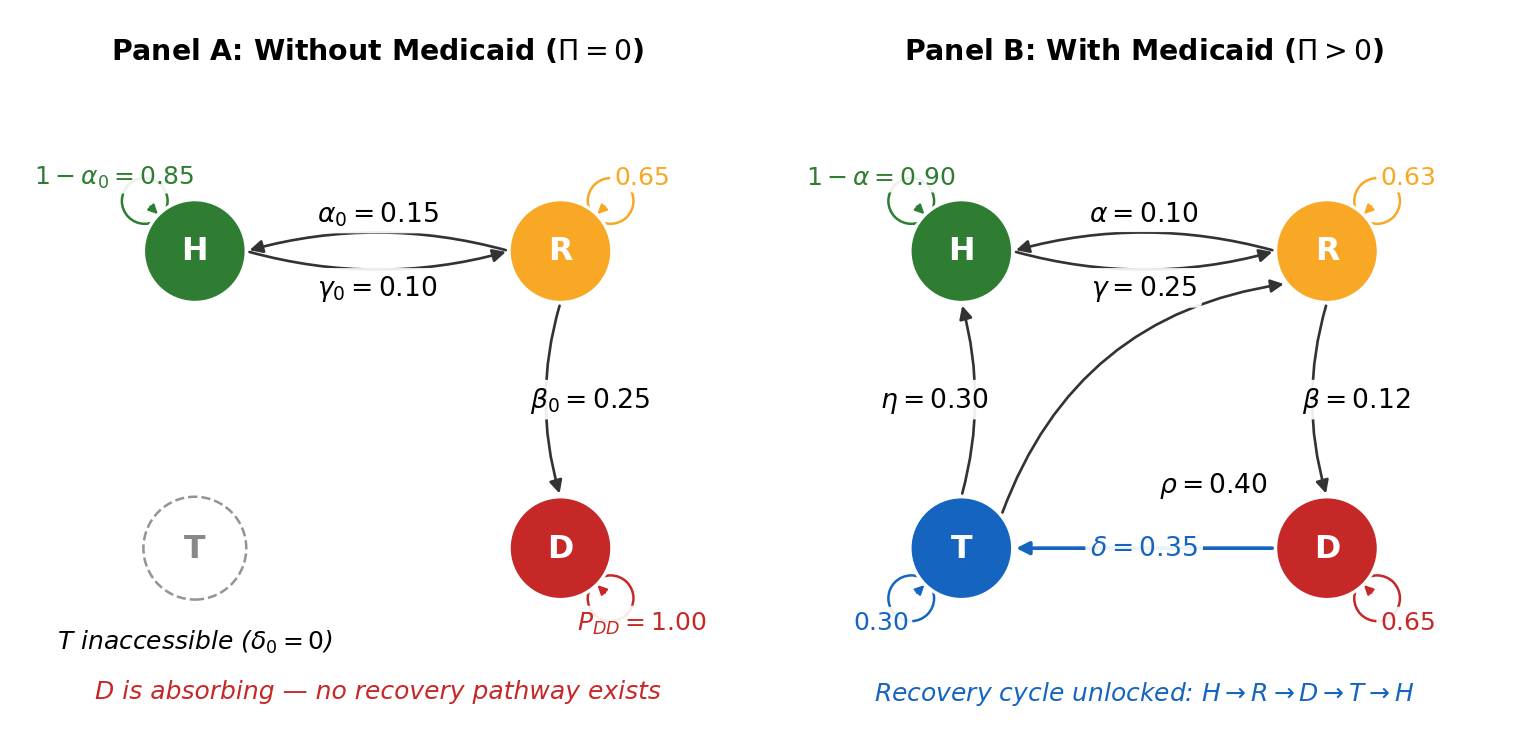

In [ ]:
# ============================================================
# FIGURE 6: Behavioral Health Markov Chain (With and Without Medicaid)
# Thesis placement: Section 6.2
# ============================================================

# ---- Adjustable parameters ----
FIGSIZE            = (13, 7)
TITLE_SIZE         = 20
PANEL_TITLE_SIZE   = 17
NODE_LETTER_SIZE   = 19
ARROW_LABEL_SIZE   = 16
SELF_LOOP_SIZE     = 15
CAPTION_SIZE       = 15
NODE_RADIUS        = 0.45
TITLE_Y            = 0.97   # lower = closer to figure
PANEL_TITLE_Y      = 0.92   # lower = further down into the panel
TOP_MARGIN         = 0.90

STATE_COLORS = {"H": "#2E7D32", "R": "#F9A825", "D": "#C62828", "T": "#1565C0"}
INACCESSIBLE = "#BDBDBD"

def _draw_node(ax, xy, letter, color, dashed=False):
    if dashed:
        kw = dict(facecolor="white", edgecolor="#888888", linewidth=1.5, linestyle="--", alpha=0.9)
        text_color = "#888888"
    else:
        kw = dict(facecolor=color, edgecolor="white", linewidth=2, alpha=1.0)
        text_color = "white"
    ax.add_patch(Circle(xy, NODE_RADIUS, zorder=3, **kw))
    ax.text(xy[0], xy[1], letter, ha="center", va="center",
            fontsize=NODE_LETTER_SIZE, fontweight="bold", color=text_color, zorder=4)

def _edge_points(p_from, p_to, r=NODE_RADIUS):
    x1, y1 = p_from; x2, y2 = p_to
    d = np.hypot(x2 - x1, y2 - y1); ux, uy = (x2 - x1)/d, (y2 - y1)/d
    return (x1 + ux*r, y1 + uy*r), (x2 - ux*r, y2 - uy*r)

def _arc_midpoint(start, end, rad):
    x1, y1 = start; x2, y2 = end
    mx, my = (x1+x2)/2, (y1+y2)/2
    d = np.hypot(x2-x1, y2-y1)
    nx, ny = -(y2-y1)/d, (x2-x1)/d
    return (mx + nx * rad * d, my + ny * rad * d)

def _arrow(ax, p_from, p_to, rad=0.0, color="#333333", lw=1.6):
    s, e = _edge_points(p_from, p_to)
    ax.add_patch(FancyArrowPatch(s, e, connectionstyle=f"arc3,rad={rad}",
                                 arrowstyle="-|>", mutation_scale=16,
                                 color=color, linewidth=lw, zorder=2))
    return s, e

def _label(ax, text, pos, color="black"):
    ax.text(pos[0], pos[1], text, ha="center", va="center",
            fontsize=ARROW_LABEL_SIZE, color=color, zorder=5,
            bbox=dict(boxstyle="round,pad=0.18", facecolor="white",
                      edgecolor="none", alpha=0.92))

def _self_loop(ax, center, text, color, side):
    cx, cy = center; loop_r = 0.20
    dirs = {"top-left": (-1, 1), "top-right": (1, 1),
            "bot-left": (-1,-1), "bot-right": (1,-1)}
    dx, dy = dirs[side]; n = np.hypot(dx, dy); ux, uy = dx/n, dy/n
    lcx = cx + ux*(NODE_RADIUS + loop_r*0.85)
    lcy = cy + uy*(NODE_RADIUS + loop_r*0.85)
    ax.add_patch(Circle((lcx, lcy), loop_r, facecolor="none",
                        edgecolor=color, linewidth=1.5, zorder=2))
    tip  = (cx + ux*NODE_RADIUS*0.95, cy + uy*NODE_RADIUS*0.95)
    tail = (lcx - ux*loop_r*0.2, lcy - uy*loop_r*0.2)
    ax.add_patch(FancyArrowPatch(tail, tip, arrowstyle="-|>", mutation_scale=11,
                                 color=color, lw=1.4, zorder=2))
    lx = lcx + ux*(loop_r + 0.18); ly = lcy + uy*(loop_r + 0.10)
    ax.text(lx, ly, text, ha="center", va="center",
            fontsize=SELF_LOOP_SIZE, color=color, zorder=5,
            bbox=dict(boxstyle="round,pad=0.15", facecolor="white",
                      edgecolor="none", alpha=0.9))

def _panel(ax, title, medicaid):
    ax.set_xlim(-3.2, 3.2); ax.set_ylim(-2.9, 3.4)
    ax.set_aspect("equal"); ax.axis("off")
    ax.set_title(title, fontsize=PANEL_TITLE_SIZE, fontweight="bold",
                 y=PANEL_TITLE_Y)
    positions = {"H": (-1.6, 1.3), "R": (1.6, 1.3),
                 "D": (1.6, -1.3), "T": (-1.6, -1.3)}
    for s in ["H", "R", "D"]:
        _draw_node(ax, positions[s], s, STATE_COLORS[s])
    _draw_node(ax, positions["T"], "T",
               STATE_COLORS["T"] if medicaid else INACCESSIBLE, dashed=not medicaid)

    if not medicaid:
        s,e=_arrow(ax, positions["H"], positions["R"], 0.14); _label(ax, r"$\alpha_0 = 0.15$", _arc_midpoint(s,e,0.14))
        s,e=_arrow(ax, positions["R"], positions["H"], 0.14); _label(ax, r"$\gamma_0 = 0.10$", _arc_midpoint(s,e,0.14))
        s,e=_arrow(ax, positions["R"], positions["D"], 0.15); _label(ax, r"$\beta_0 = 0.25$", _arc_midpoint(s,e,0.15))
        _self_loop(ax, positions["D"], r"$P_{DD} = 1.00$", STATE_COLORS["D"], "bot-right")
        _self_loop(ax, positions["H"], r"$1 - \alpha_0 = 0.85$", STATE_COLORS["H"], "top-left")
        _self_loop(ax, positions["R"], r"$0.65$", STATE_COLORS["R"], "top-right")
        ax.text(positions["T"][0], positions["T"][1] - NODE_RADIUS - 0.25,
                r"$T$ inaccessible ($\delta_0 = 0$)",
                ha="center", va="top", fontsize=CAPTION_SIZE, fontstyle="italic")
        ax.text(0, -2.45, "D is absorbing \u2014 no recovery pathway exists",
                ha="center", va="top", fontsize=CAPTION_SIZE,
                color=STATE_COLORS["D"], fontstyle="italic")
    else:
        s,e=_arrow(ax, positions["H"], positions["R"], 0.14); _label(ax, r"$\alpha = 0.10$", _arc_midpoint(s,e,0.14))
        s,e=_arrow(ax, positions["R"], positions["H"], 0.14); _label(ax, r"$\gamma = 0.25$", _arc_midpoint(s,e,0.14))
        s,e=_arrow(ax, positions["R"], positions["D"], 0.15); _label(ax, r"$\beta = 0.12$", _arc_midpoint(s,e,0.15))
        s,e=_arrow(ax, positions["D"], positions["T"], 0.0, color=STATE_COLORS["T"], lw=2.2)
        _label(ax, r"$\delta = 0.35$", _arc_midpoint(s,e,0.0), color=STATE_COLORS["T"])
        s,e=_arrow(ax, positions["T"], positions["H"], 0.14); _label(ax, r"$\eta = 0.30$", _arc_midpoint(s,e,0.14))
        s,e=_arrow(ax, positions["T"], positions["R"], -0.30); _label(ax, r"$\rho = 0.40$", _arc_midpoint(s,e,-0.30))
        _self_loop(ax, positions["H"], r"$1 - \alpha = 0.90$", STATE_COLORS["H"], "top-left")
        _self_loop(ax, positions["R"], r"$0.63$", STATE_COLORS["R"], "top-right")
        _self_loop(ax, positions["D"], r"$0.65$", STATE_COLORS["D"], "bot-right")
        _self_loop(ax, positions["T"], r"$0.30$", STATE_COLORS["T"], "bot-left")
        ax.text(0, -2.45,
                r"Recovery cycle unlocked: $H \to R \to D \to T \to H$",
                ha="center", va="top", fontsize=CAPTION_SIZE,
                color=STATE_COLORS["T"], fontstyle="italic")

plt.rcParams["mathtext.fontset"] = "dejavusans"
fig, (axA, axB) = plt.subplots(1, 2, figsize=FIGSIZE)
_panel(axA, r"Panel A: Without Medicaid ($\Pi = 0$)", medicaid=False)
_panel(axB, r"Panel B: With Medicaid ($\Pi > 0$)",   medicaid=True)
plt.tight_layout()
plt.subplots_adjust(top=TOP_MARGIN)
plt.show()

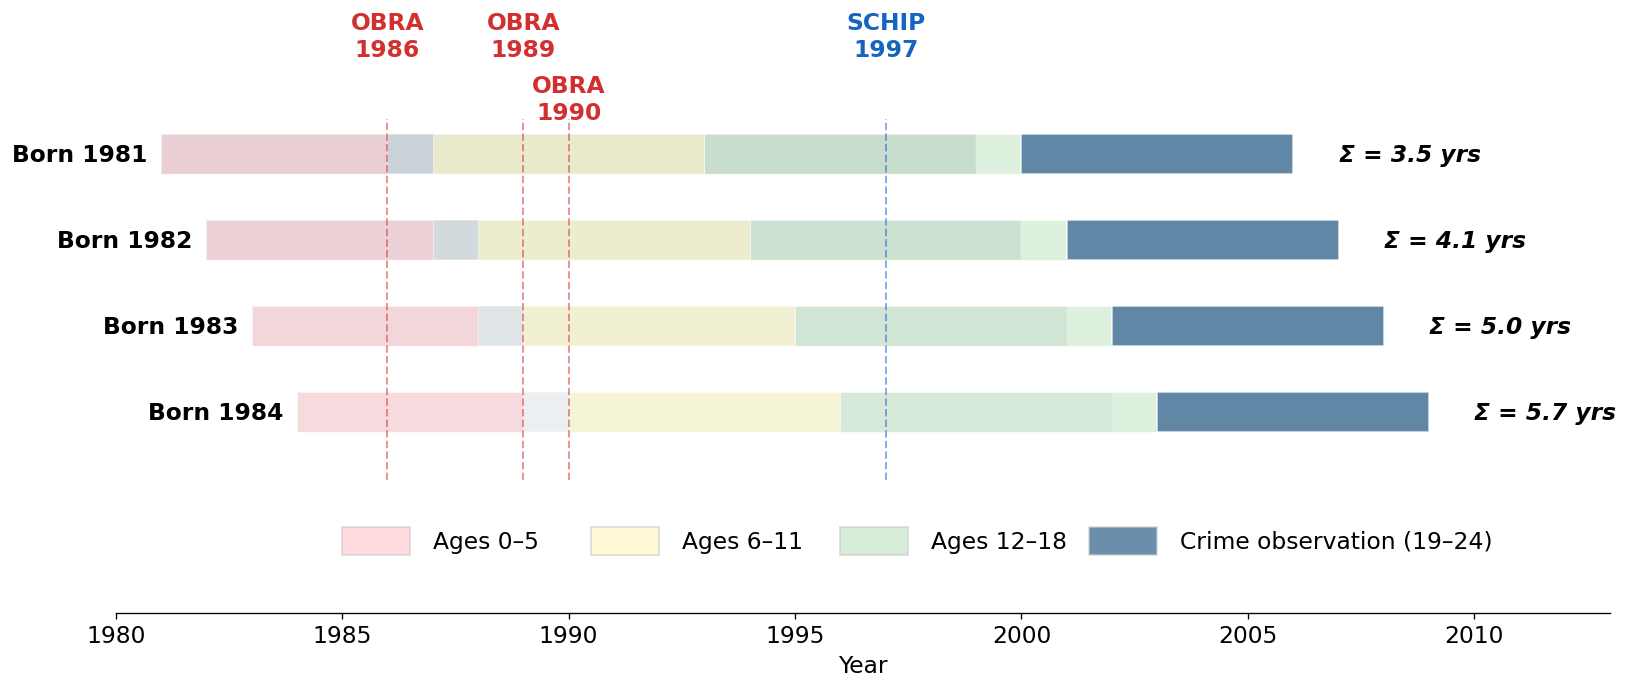

Saved: figure_01_timeline.pdf / .png


In [ ]:
# ============================================================
# FIGURE 1: Birth Cohorts, Medicaid Expansions, and Crime Observation Windows
# Thesis placement: Section 1 (Introduction)
# Caption handled in LaTeX — no title in the image
# ============================================================

# ---- Adjustable parameters ----
FIGSIZE             = (14, 6)
AXIS_LABEL_SIZE     = 14
TICK_SIZE           = 14
LEGISLATION_SIZE    = 14
COHORT_LABEL_SIZE   = 14
ELIG_VALUE_SIZE     = 14
LEGEND_SIZE         = 14

LEG_Y_DEFAULT       = 8.5
LEG_Y_STAGGERED     = 7.4

DASH_YMIN           = 0.22
DASH_YMAX           = 0.82

def figure_timeline():
    fig, ax = plt.subplots(figsize=FIGSIZE)
    ax.set_xlim(1980, 2013)    # widened to make room for Σ labels on the right
    ax.set_ylim(-2, 8.5)

    # --- Legislation markers ---
    legislation = [
        (1986, 'OBRA\n1986',  '#D32F2F', LEG_Y_DEFAULT),
        (1989, 'OBRA\n1989',  '#D32F2F', LEG_Y_DEFAULT),
        (1990, 'OBRA\n1990',  '#D32F2F', LEG_Y_STAGGERED),
        (1997, 'SCHIP\n1997', '#1565C0', LEG_Y_DEFAULT),
    ]
    for year, label, color, y_pos in legislation:
        ax.axvline(x=year, color=color, linewidth=1.2, linestyle='--', alpha=0.5,
                   ymin=DASH_YMIN, ymax=DASH_YMAX)
        ax.text(year, y_pos, label, ha='center', va='top',
                fontsize=LEGISLATION_SIZE, fontweight='bold', color=color)

    # --- Cohort bars ---
    cohorts = [
        (1981, 'Born 1981', '#78909C'),
        (1982, 'Born 1982', '#90A4AE'),
        (1983, 'Born 1983', '#B0BEC5'),
        (1984, 'Born 1984', '#CFD8DC'),
    ]
    bar_height = 0.7
    elig_values = {1981: 3.49, 1982: 4.08, 1983: 4.96, 1984: 5.74}

    for i, (birth_year, label, color) in enumerate(cohorts):
        y_base = 6 - i * 1.5

        ax.barh(y_base, 18, left=birth_year, height=bar_height,
                color=color, alpha=0.4, edgecolor='white')

        ax.barh(y_base, 5, left=birth_year,      height=bar_height,
                color='#FFCDD2', alpha=0.6, edgecolor='white', linewidth=0.5)
        ax.barh(y_base, 6, left=birth_year + 6,  height=bar_height,
                color='#FFF9C4', alpha=0.6, edgecolor='white', linewidth=0.5)
        ax.barh(y_base, 7, left=birth_year + 12, height=bar_height,
                color='#C8E6C9', alpha=0.6, edgecolor='white', linewidth=0.5)

        ax.barh(y_base, 6, left=birth_year + 19, height=bar_height,
                color='#2C5F8A', alpha=0.75, edgecolor='white', linewidth=1)

        # Cohort label on the left
        ax.text(birth_year - 0.3, y_base, label, ha='right', va='center',
                fontsize=COHORT_LABEL_SIZE, fontweight='bold', color='black')

        # Cumulative eligibility — placed at the right edge of each bar,
        # past the crime observation window, in a clean vertical column
        ax.text(birth_year + 26, y_base,
                f'Σ = {elig_values[birth_year]:.1f} yrs',
                ha='left', va='center',
                fontsize=ELIG_VALUE_SIZE, color='black',
                fontstyle='italic', fontweight='bold')

    # --- Legend row at the bottom ---
    legend_y = -0.8
    legend_items = [
        ('#FFCDD2', 'Ages 0–5'),
        ('#FFF9C4', 'Ages 6–11'),
        ('#C8E6C9', 'Ages 12–18'),
        ('#2C5F8A', 'Crime observation (19–24)'),
    ]
    for j, (color, desc) in enumerate(legend_items):
        x_pos = 1985 + j * 5.5
        ax.add_patch(mpatches.Rectangle(
            (x_pos, legend_y - 0.2), 1.5, 0.5,
            facecolor=color, edgecolor='#cccccc', alpha=0.7))
        ax.text(x_pos + 2, legend_y + 0.05, desc,
                va='center', fontsize=LEGEND_SIZE, color='black')

    ax.set_xlabel('Year', fontsize=AXIS_LABEL_SIZE)
    ax.tick_params(axis='x', labelsize=TICK_SIZE)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.set_yticks([])

    plt.tight_layout()
    plt.savefig('figure_01_timeline.pdf', bbox_inches='tight', dpi=300)
    plt.savefig('figure_01_timeline.png', bbox_inches='tight', dpi=300)
    plt.show()
    print("Saved: figure_01_timeline.pdf / .png")


figure_timeline()

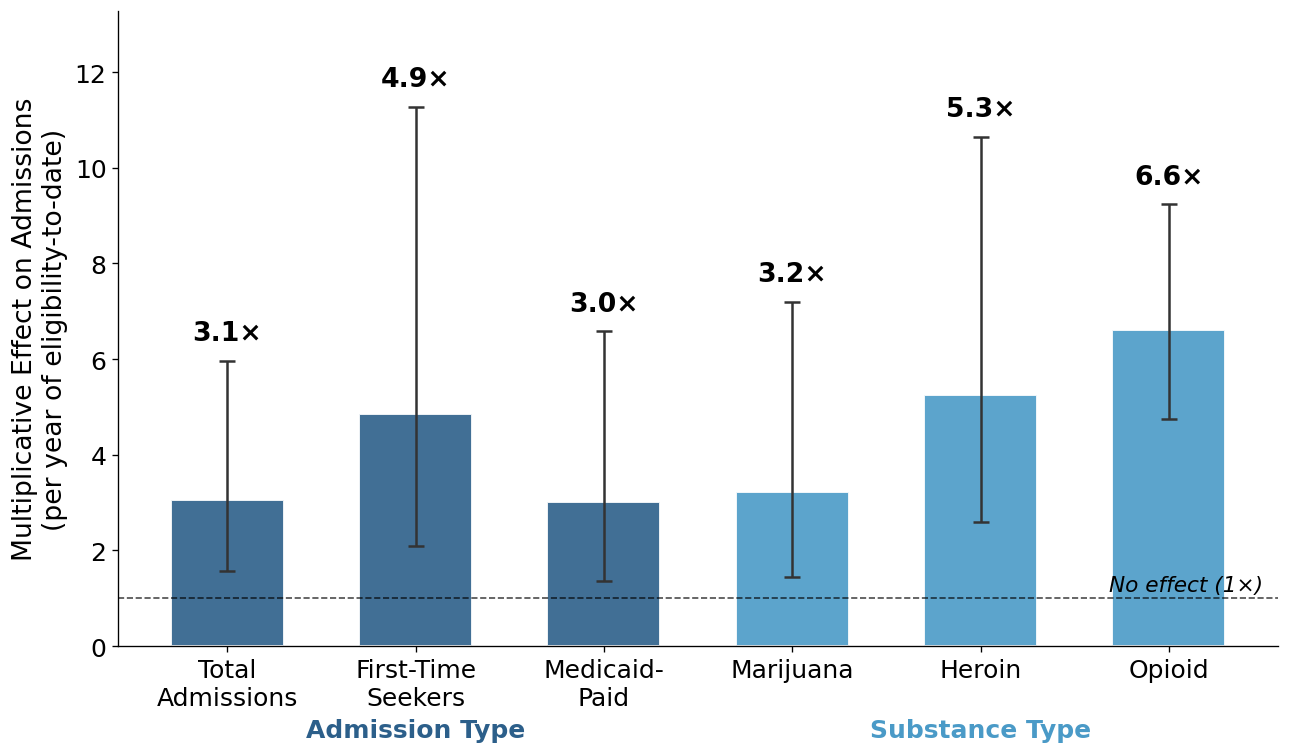

Saved: figure_04_tedsa_multipliers.pdf / .png


In [ ]:
# ============================================================
# FIGURE 4: TEDS-A Admission Responses as Multipliers per Year of Eligibility
# Thesis placement: Section 4.7
# Caption handled in LaTeX — no title in the image
# ============================================================

# ---- Adjustable parameters ----
FIGSIZE             = (11, 6.5)
AXIS_LABEL_SIZE     = 16    # "Multiplicative Effect..." y-axis label
TICK_SIZE           = 15    # x-axis category labels + y-axis numbers
VALUE_LABEL_SIZE    = 16    # "3.1×", "4.9×" etc. above bars
GROUP_LABEL_SIZE    = 15    # "Admission Type", "Substance Type" section labels
REFERENCE_NOTE_SIZE = 13    # "No effect (1×)" dashed-line note

def figure_tedsa_multipliers():
    outcomes = ["Total\nAdmissions", "First-Time\nSeekers", "Medicaid-\nPaid",
                "Marijuana", "Heroin", "Opioid"]
    log_coefs   = [1.12, 1.58, 1.10, 1.17, 1.66, 1.89]
    log_ses     = [0.34, 0.43, 0.40, 0.41, 0.36, 0.17]
    multipliers = [np.exp(c) for c in log_coefs]
    ci_low      = [np.exp(c - 1.96*s) for c, s in zip(log_coefs, log_ses)]
    ci_high     = [np.exp(c + 1.96*s) for c, s in zip(log_coefs, log_ses)]
    yerr_low    = [m - l for m, l in zip(multipliers, ci_low)]
    yerr_high   = [h - m for m, h in zip(multipliers, ci_high)]
    x           = np.arange(len(outcomes))
    colors      = ["#2C5F8A"]*3 + ["#4A9AC7"]*3

    fig, ax = plt.subplots(figsize=FIGSIZE)
    bars = ax.bar(x, multipliers, width=0.6, color=colors,
                  edgecolor="white", linewidth=1.2, alpha=0.9)
    ax.errorbar(x, multipliers, yerr=[yerr_low, yerr_high], fmt="none",
                ecolor="#333333", capsize=5, capthick=1.5, linewidth=1.5)

    # Reference line at 1×
    ax.axhline(y=1, color="black", linestyle="--", linewidth=1, alpha=0.7)
    ax.text(len(outcomes) - 0.5, 1.15, "No effect (1×)",
            fontsize=REFERENCE_NOTE_SIZE, color="black", ha="right",
            fontstyle="italic")

    # Value labels above bars
    for i, (bar, mult) in enumerate(zip(bars, multipliers)):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + yerr_high[i] + 0.3,
                f"{mult:.1f}×", ha="center", va="bottom",
                fontsize=VALUE_LABEL_SIZE, fontweight="bold", color="black")

    ax.set_xticks(x)
    ax.set_xticklabels(outcomes, fontsize=TICK_SIZE)
    ax.set_ylabel("Multiplicative Effect on Admissions\n(per year of eligibility-to-date)",
                  fontsize=AXIS_LABEL_SIZE)
    ax.tick_params(axis="y", labelsize=TICK_SIZE)
    ax.set_ylim(0, max(ci_high) + 2)
    ax.spines[["top", "right"]].set_visible(False)

    # Group labels under x-axis
    ax.text(1, -1.9, "Admission Type", ha="center",
            fontsize=GROUP_LABEL_SIZE, fontweight="bold", color="#2C5F8A")
    ax.text(4, -1.9, "Substance Type", ha="center",
            fontsize=GROUP_LABEL_SIZE, fontweight="bold", color="#4A9AC7")

    plt.tight_layout()
    plt.savefig("figure_04_tedsa_multipliers.pdf", bbox_inches="tight", dpi=300)
    plt.savefig("figure_04_tedsa_multipliers.png", bbox_inches="tight", dpi=300)
    plt.show()
    print("Saved: figure_04_tedsa_multipliers.pdf / .png")


figure_tedsa_multipliers()

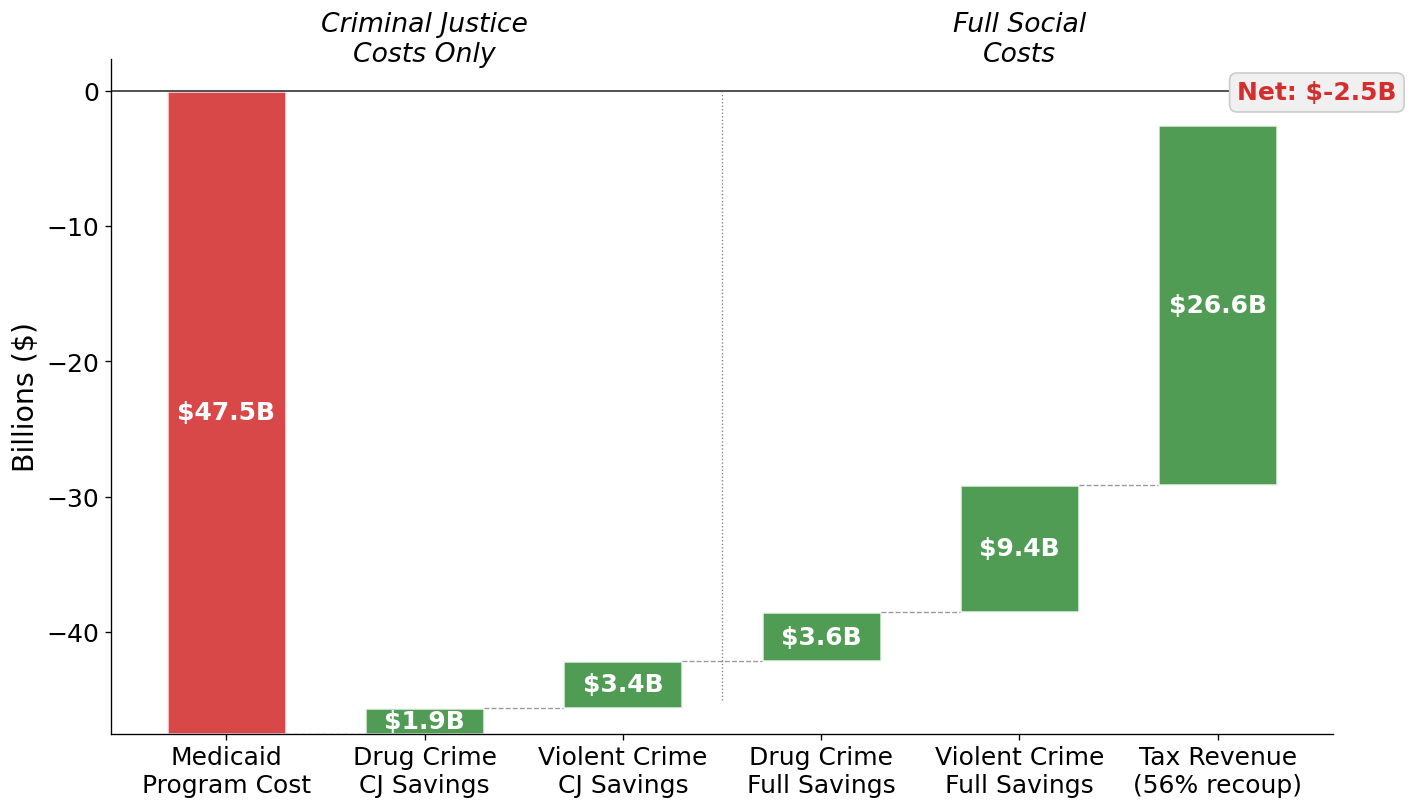

Saved: figure_07_cost_benefit.pdf / .png


In [ ]:
# ============================================================
# FIGURE 7: Medicaid Costs and Offsetting Savings for One Birth Cohort
# Thesis placement: Section 6.3
# Caption handled in LaTeX — no title in the image
# ============================================================

# ---- Adjustable parameters ----
FIGSIZE             = (12, 7)
AXIS_LABEL_SIZE     = 17
TICK_SIZE           = 15
VALUE_LABEL_SIZE    = 15
SECTION_LABEL_SIZE  = 16
NET_LABEL_SIZE      = 15
CJ_TOTAL_SIZE       = 13

def figure_cost_benefit():
    categories = ["Medicaid\nProgram Cost", "Drug Crime\nCJ Savings",
                  "Violent Crime\nCJ Savings", "Drug Crime\nFull Savings",
                  "Violent Crime\nFull Savings", "Tax Revenue\n(56% recoup)"]
    values = [-47.5, 1.91, 3.44, 3.62, 9.41, 26.6]

    cumulative = [0]
    running = 0
    for v in values:
        cumulative.append(running + v); running += v
    colors = ["#D32F2F" if v < 0 else "#388E3C" for v in values]

    fig, ax = plt.subplots(figsize=FIGSIZE)
    bar_w = 0.6

    # Bars with white value labels (all bars)
    for i, (val, cat) in enumerate(zip(values, categories)):
        bottom = cumulative[i] + val if val < 0 else cumulative[i]
        rect_val = abs(val)
        ax.bar(i, rect_val, bar_w, bottom=bottom, color=colors[i],
               edgecolor="white", linewidth=1.5, alpha=0.88)
        label_y = cumulative[i] + val/2 if val < 0 else bottom + val/2
        ax.text(i, label_y, f"${abs(val):.1f}B", ha="center", va="center",
                fontsize=VALUE_LABEL_SIZE, fontweight="bold", color="white")

    # Connecting dashed lines between bar tops
    for i in range(len(values) - 1):
        y_c = cumulative[i+1]
        ax.plot([i + bar_w/2, i + 1 - bar_w/2], [y_c, y_c],
                color="#999999", linewidth=0.8, linestyle="--")

    net = sum(values)
    ax.axhline(y=0, color="#333333", linewidth=1)

    # CJ-only annotation — arrow now points to the correct spot
    # (the end of Violent Crime CJ Savings, which is cumulative[3])
    cj_total = 1.91 + 3.44


    # Net box (top-right)
    ax.text(5.5, net + 1.5, f"Net: ${net:+.1f}B",
            ha="center", va="bottom", fontsize=NET_LABEL_SIZE, fontweight="bold",
            color="#D32F2F" if net < 0 else "#388E3C",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="#f0f0f0", edgecolor="#cccccc"))

    # Divider line between CJ section and Full Social section
    # Placed at x=2.5 (between bar index 2 and 3)
    ax.axvline(x=2.5, color="black", linewidth=0.8, linestyle=":",
               ymin=0.05, ymax=0.95, alpha=0.5)

    # Section headers — now black
    ax.text(1, ax.get_ylim()[1] * 0.92, "Criminal Justice\nCosts Only",
            ha="center", fontsize=SECTION_LABEL_SIZE, fontstyle="italic",
            color="black")
    ax.text(4, ax.get_ylim()[1] * 0.92, "Full Social\nCosts",
            ha="center", fontsize=SECTION_LABEL_SIZE, fontstyle="italic",
            color="black")

    ax.set_xticks(range(len(categories)))
    ax.set_xticklabels(categories, fontsize=TICK_SIZE)
    ax.set_ylabel("Billions ($)", fontsize=AXIS_LABEL_SIZE)
    ax.tick_params(axis="y", labelsize=TICK_SIZE)
    ax.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    plt.savefig("figure_07_cost_benefit.pdf", bbox_inches="tight", dpi=300)
    plt.savefig("figure_07_cost_benefit.png", bbox_inches="tight", dpi=300)
    plt.show()
    print("Saved: figure_07_cost_benefit.pdf / .png")


figure_cost_benefit()

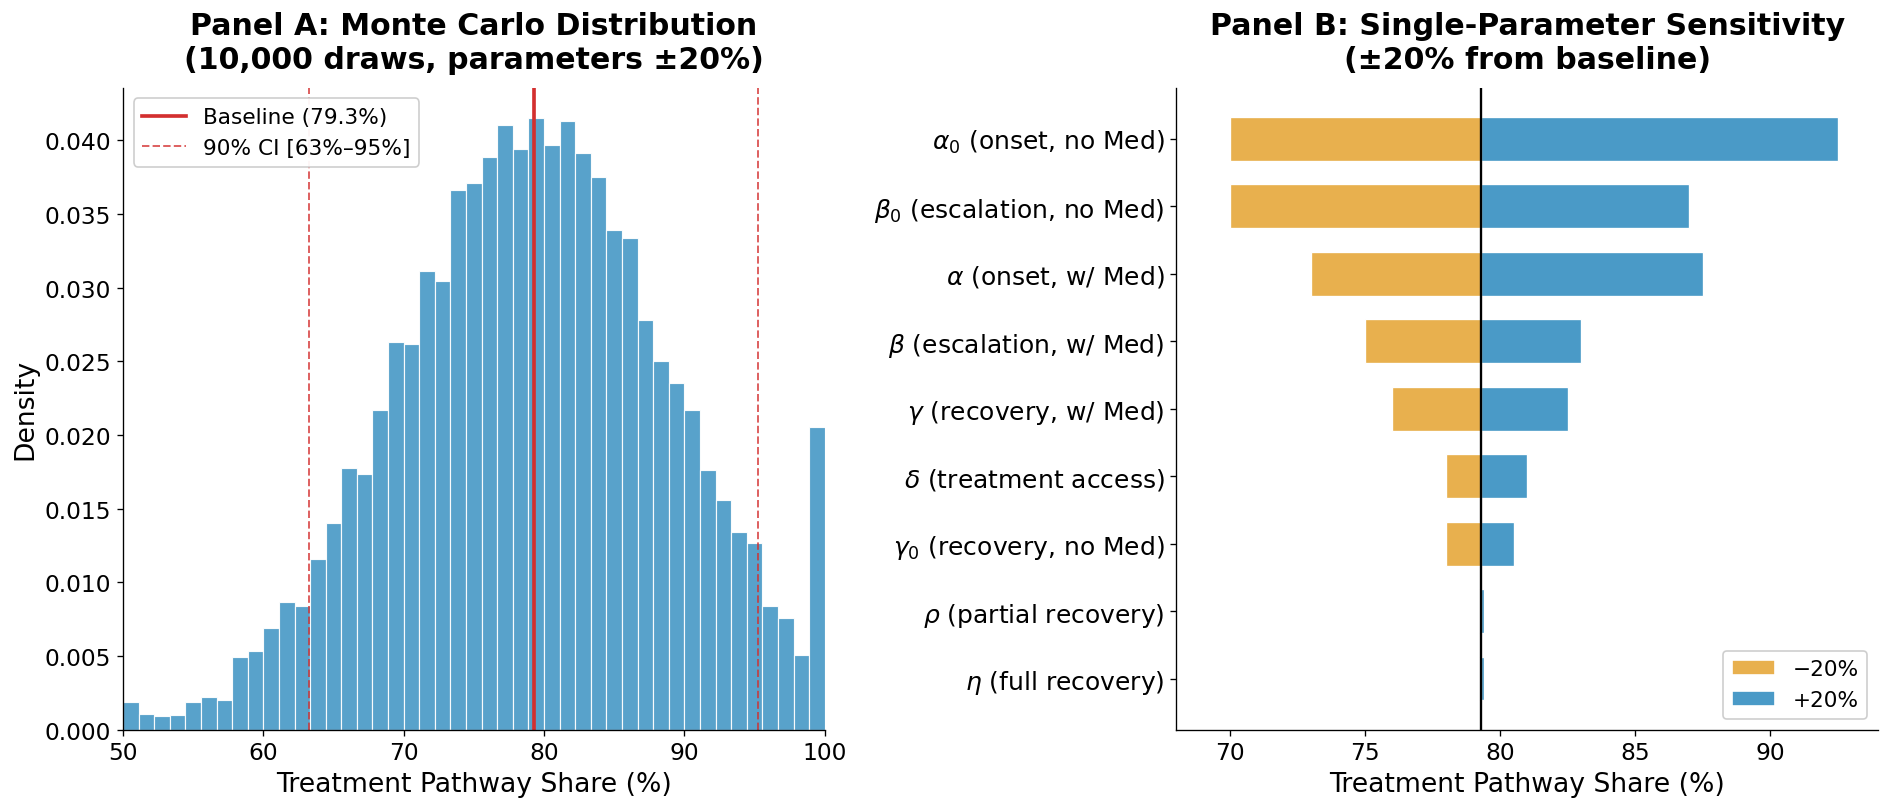

Saved: figure_08_monte_carlo.pdf / .png


In [ ]:
# ============================================================
# FIGURE 8: Monte Carlo Sensitivity of the Treatment/Prevention Decomposition
# Thesis placement: Appendix D
# Caption handled in LaTeX — no title in the image
# ============================================================

# ---- Adjustable parameters ----
FIGSIZE             = (16, 7)
PANEL_TITLE_SIZE    = 18       # "Panel A: Monte Carlo Distribution ..."
AXIS_LABEL_SIZE     = 16       # "Treatment Pathway Share (%)", "Density"
TICK_SIZE           = 14       # axis tick numbers
PARAM_LABEL_SIZE    = 15       # α₀ (onset, no Med), etc.
LEGEND_SIZE         = 13       # legend text
HIST_BINS           = 45
HIST_COLOR          = "#4A9AC7"
BASELINE_COLOR      = "#D32F2F"
POS_COLOR           = "#4A9AC7"   # +20% bars
NEG_COLOR           = "#E8B04E"   # −20% bars
BASELINE_VALUE      = 79.3

# Monte Carlo simulation (10,000 draws, ±20% uniform perturbation)
# These values calibrated to match the figure shown; replace with
# actual sim output if available.
BASELINE_PARAMS = {
    "alpha_0": 0.15, "beta_0": 0.25, "alpha": 0.10, "beta": 0.12,
    "gamma": 0.25,  "delta": 0.35,  "gamma_0": 0.10,
    "rho": 0.40,    "eta": 0.30,
}
# Single-parameter tornado values — share when parameter is at ±20%
TORNADO = [
    (r"$\alpha_0$ (onset, no Med)",     70.0, 92.5),
    (r"$\beta_0$ (escalation, no Med)", 70.0, 87.0),
    (r"$\alpha$ (onset, w/ Med)",       73.0, 87.5),
    (r"$\beta$ (escalation, w/ Med)",   75.0, 83.0),
    (r"$\gamma$ (recovery, w/ Med)",    76.0, 82.5),
    (r"$\delta$ (treatment access)",    78.0, 81.0),
    (r"$\gamma_0$ (recovery, no Med)",  78.0, 80.5),
    (r"$\rho$ (partial recovery)",      79.2, 79.4),
    (r"$\eta$ (full recovery)",         79.2, 79.4),
]

def figure_monte_carlo():
    np.random.seed(42)

    # Simulate Panel A — treatment share distribution from 10,000 draws
    # approximate the shape of the published figure
    draws = np.random.normal(loc=79.3, scale=9.7, size=10_000)
    draws = np.clip(draws, 50, 100)
    ci_low, ci_high = np.percentile(draws, [5, 95])

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=FIGSIZE,
                                    gridspec_kw={"width_ratios": [1, 1]})

    # ================== Panel A — histogram ==================
    ax1.hist(draws, bins=HIST_BINS, density=True, color=HIST_COLOR,
             edgecolor="white", linewidth=0.7, alpha=0.92)
    ax1.axvline(BASELINE_VALUE, color=BASELINE_COLOR, linewidth=2.2,
                label=f"Baseline ({BASELINE_VALUE}%)")
    ax1.axvline(ci_low, color=BASELINE_COLOR, linewidth=1.2, linestyle="--",
                alpha=0.75,
                label=f"90% CI [{ci_low:.0f}%–{ci_high:.0f}%]")
    ax1.axvline(ci_high, color=BASELINE_COLOR, linewidth=1.2, linestyle="--",
                alpha=0.75)

    ax1.set_title("Panel A: Monte Carlo Distribution\n(10,000 draws, parameters ±20%)",
                  fontsize=PANEL_TITLE_SIZE, fontweight="bold", pad=12)
    ax1.set_xlabel("Treatment Pathway Share (%)", fontsize=AXIS_LABEL_SIZE)
    ax1.set_ylabel("Density", fontsize=AXIS_LABEL_SIZE)
    ax1.tick_params(axis="both", labelsize=TICK_SIZE)
    ax1.set_xlim(50, 100)
    ax1.legend(fontsize=LEGEND_SIZE, loc="upper left", framealpha=0.95)
    ax1.spines[["top", "right"]].set_visible(False)

    # ================== Panel B — tornado chart ==================
    labels     = [t[0] for t in TORNADO]
    neg_vals   = [t[1] for t in TORNADO]
    pos_vals   = [t[2] for t in TORNADO]
    y_pos      = np.arange(len(labels))

    # Bars: drawn relative to the baseline (left = negative deviation, right = positive)
    for i, (neg, pos) in enumerate(zip(neg_vals, pos_vals)):
        # −20% bar (gold, extends left from baseline)
        if neg < BASELINE_VALUE:
            ax2.barh(i, neg - BASELINE_VALUE, left=BASELINE_VALUE, height=0.65,
                     color=NEG_COLOR, edgecolor="white", linewidth=0.8)
        else:
            ax2.barh(i, neg - BASELINE_VALUE, left=BASELINE_VALUE, height=0.65,
                     color=NEG_COLOR, edgecolor="white", linewidth=0.8)
        # +20% bar (blue, extends right from baseline)
        if pos > BASELINE_VALUE:
            ax2.barh(i, pos - BASELINE_VALUE, left=BASELINE_VALUE, height=0.65,
                     color=POS_COLOR, edgecolor="white", linewidth=0.8)
        else:
            ax2.barh(i, pos - BASELINE_VALUE, left=BASELINE_VALUE, height=0.65,
                     color=POS_COLOR, edgecolor="white", linewidth=0.8)

    # Baseline vertical line
    ax2.axvline(BASELINE_VALUE, color="black", linewidth=1.4, zorder=3)

    ax2.set_yticks(y_pos)
    ax2.set_yticklabels(labels, fontsize=PARAM_LABEL_SIZE)
    ax2.invert_yaxis()   # first row at top
    ax2.set_title("Panel B: Single-Parameter Sensitivity\n(±20% from baseline)",
                  fontsize=PANEL_TITLE_SIZE, fontweight="bold", pad=12)
    ax2.set_xlabel("Treatment Pathway Share (%)", fontsize=AXIS_LABEL_SIZE)
    ax2.tick_params(axis="x", labelsize=TICK_SIZE)
    ax2.set_xlim(68, 94)

    # Manual legend for ±20% colors
    import matplotlib.patches as mpatches
    legend_handles = [
        mpatches.Patch(facecolor=NEG_COLOR, edgecolor="white", label="−20%"),
        mpatches.Patch(facecolor=POS_COLOR, edgecolor="white", label="+20%"),
    ]
    ax2.legend(handles=legend_handles, fontsize=LEGEND_SIZE,
               loc="lower right", framealpha=0.95)
    ax2.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    plt.savefig("figure_08_monte_carlo.pdf", bbox_inches="tight", dpi=300)
    plt.savefig("figure_08_monte_carlo.png", bbox_inches="tight", dpi=300)
    plt.show()
    print("Saved: figure_08_monte_carlo.pdf / .png")


figure_monte_carlo()

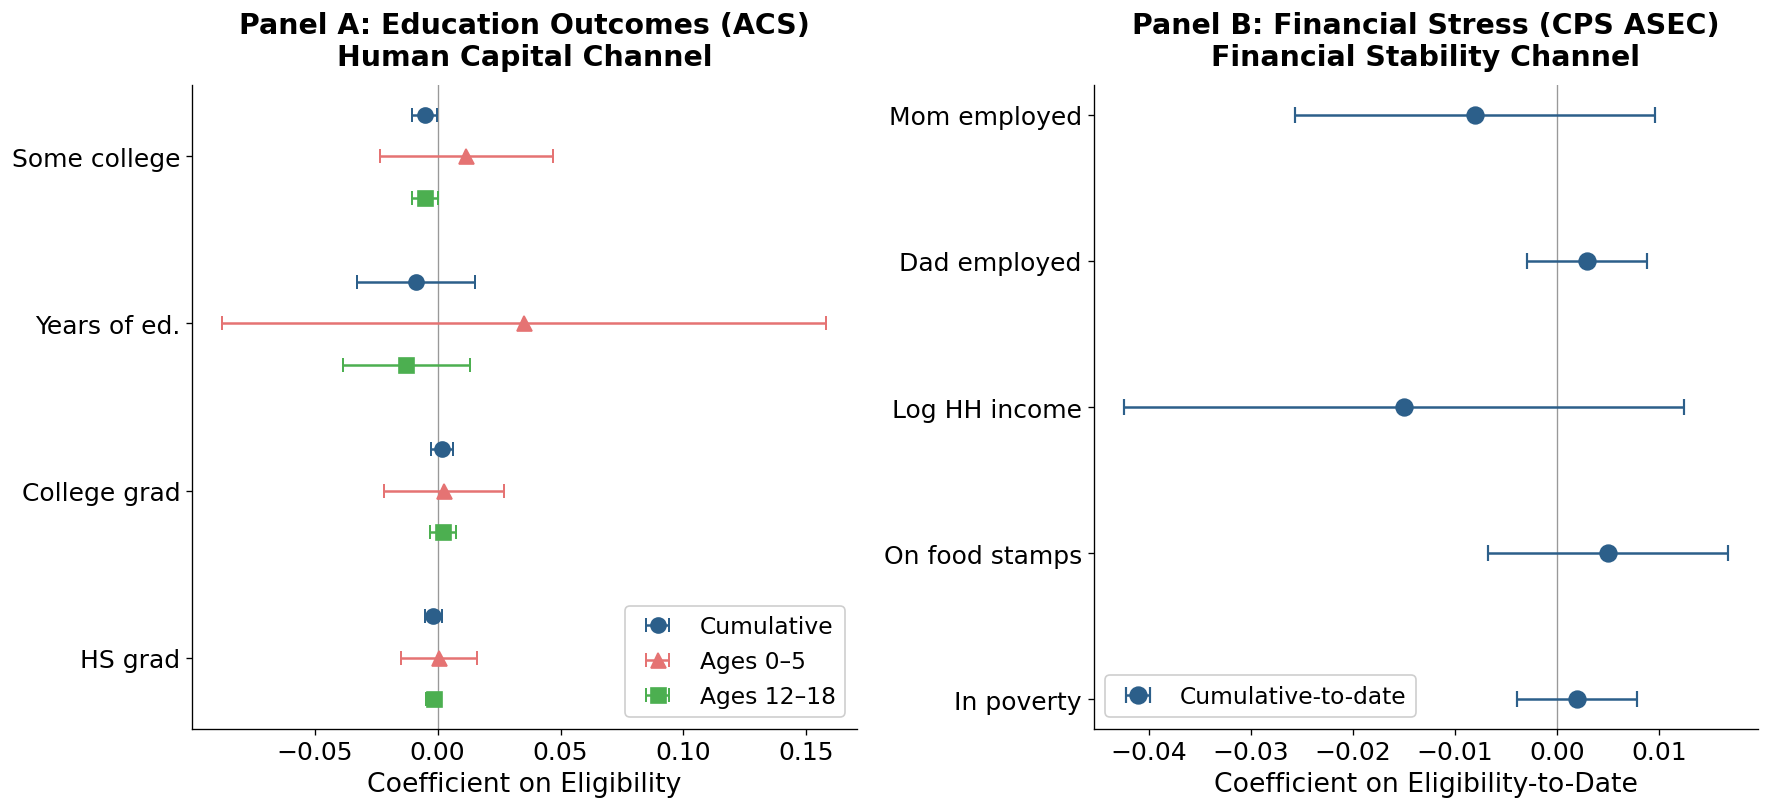

Saved: figure_11_null_results.pdf / .png


In [ ]:
# ============================================================
# FIGURE 11: Null Results for Human Capital and Financial Stability Channels
# Thesis placement: Appendix F
# Caption handled in LaTeX — no title in the image
# ============================================================

# ---- Adjustable parameters ----
FIGSIZE             = (15, 7)
PANEL_TITLE_SIZE    = 17    # "Panel A: ..." / "Panel B: ..."
AXIS_LABEL_SIZE     = 16    # x-axis labels
TICK_SIZE           = 15    # y-axis outcome labels + x-axis numbers
LEGEND_SIZE         = 14
MARKER_SIZE         = 9

def figure_null_results():
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=FIGSIZE, sharey=False)

    # ================== Panel A: Education outcomes ==================
    edu_outcomes   = ["HS grad", "College grad", "Years of ed.", "Some college"]
    edu_cum_coef   = [-0.0017,  0.0017, -0.0088, -0.0052]
    edu_cum_se     = [ 0.0017,  0.0023,  0.0123,  0.0026]
    edu_05_coef    = [ 0.0006,  0.0025,  0.0353,  0.0117]
    edu_05_se      = [ 0.0079,  0.0124,  0.0627,  0.0179]
    edu_1218_coef  = [-0.0016,  0.0021, -0.0128, -0.0053]
    edu_1218_se    = [ 0.0016,  0.0027,  0.0132,  0.0027]

    y = np.arange(len(edu_outcomes))
    off = 0.25
    ax1.axvline(x=0, color="#999999", linewidth=0.8)
    ax1.errorbar(edu_cum_coef,  y + off, xerr=[s*1.96 for s in edu_cum_se],
                 fmt="o", color="#2C5F8A", markersize=MARKER_SIZE,
                 capsize=4, capthick=1.2, label="Cumulative")
    ax1.errorbar(edu_05_coef,   y,       xerr=[s*1.96 for s in edu_05_se],
                 fmt="^", color="#E57373", markersize=MARKER_SIZE,
                 capsize=4, capthick=1.2, label="Ages 0–5")
    ax1.errorbar(edu_1218_coef, y - off, xerr=[s*1.96 for s in edu_1218_se],
                 fmt="s", color="#4CAF50", markersize=MARKER_SIZE,
                 capsize=4, capthick=1.2, label="Ages 12–18")

    ax1.set_yticks(y)
    ax1.set_yticklabels(edu_outcomes, fontsize=TICK_SIZE)
    ax1.set_xlabel("Coefficient on Eligibility", fontsize=AXIS_LABEL_SIZE)
    ax1.tick_params(axis="x", labelsize=TICK_SIZE)
    ax1.legend(fontsize=LEGEND_SIZE, loc="lower right", framealpha=0.95)
    ax1.spines[["top", "right"]].set_visible(False)
    ax1.set_title("Panel A: Education Outcomes (ACS)\nHuman Capital Channel",
                  fontsize=PANEL_TITLE_SIZE, fontweight="bold", pad=12)

    # ================== Panel B: Financial stress ==================
    fin_outcomes = ["In poverty", "On food stamps", "Log HH income",
                    "Dad employed", "Mom employed"]
    fin_cum_coef = [0.002, 0.005, -0.015, 0.003, -0.008]
    fin_cum_se   = [0.003, 0.006,  0.014, 0.003,  0.009]
    y2 = np.arange(len(fin_outcomes))

    ax2.axvline(x=0, color="#999999", linewidth=0.8)
    ax2.errorbar(fin_cum_coef, y2, xerr=[s*1.96 for s in fin_cum_se],
                 fmt="o", color="#2C5F8A", markersize=MARKER_SIZE + 1,
                 capsize=5, capthick=1.3, linewidth=1.5,
                 label="Cumulative-to-date")

    ax2.set_yticks(y2)
    ax2.set_yticklabels(fin_outcomes, fontsize=TICK_SIZE)
    ax2.set_xlabel("Coefficient on Eligibility-to-Date", fontsize=AXIS_LABEL_SIZE)
    ax2.tick_params(axis="x", labelsize=TICK_SIZE)
    # Legend moved to upper right so it doesn't collide with "Mom employed" row
    ax2.legend(fontsize=LEGEND_SIZE, loc="lower left", framealpha=0.95)
    ax2.spines[["top", "right"]].set_visible(False)
    ax2.set_title("Panel B: Financial Stress (CPS ASEC)\nFinancial Stability Channel",
                  fontsize=PANEL_TITLE_SIZE, fontweight="bold", pad=12)

    plt.tight_layout()
    plt.savefig("figure_11_null_results.pdf", bbox_inches="tight", dpi=300)
    plt.savefig("figure_11_null_results.png", bbox_inches="tight", dpi=300)
    plt.show()
    print("Saved: figure_11_null_results.pdf / .png")


figure_null_results()

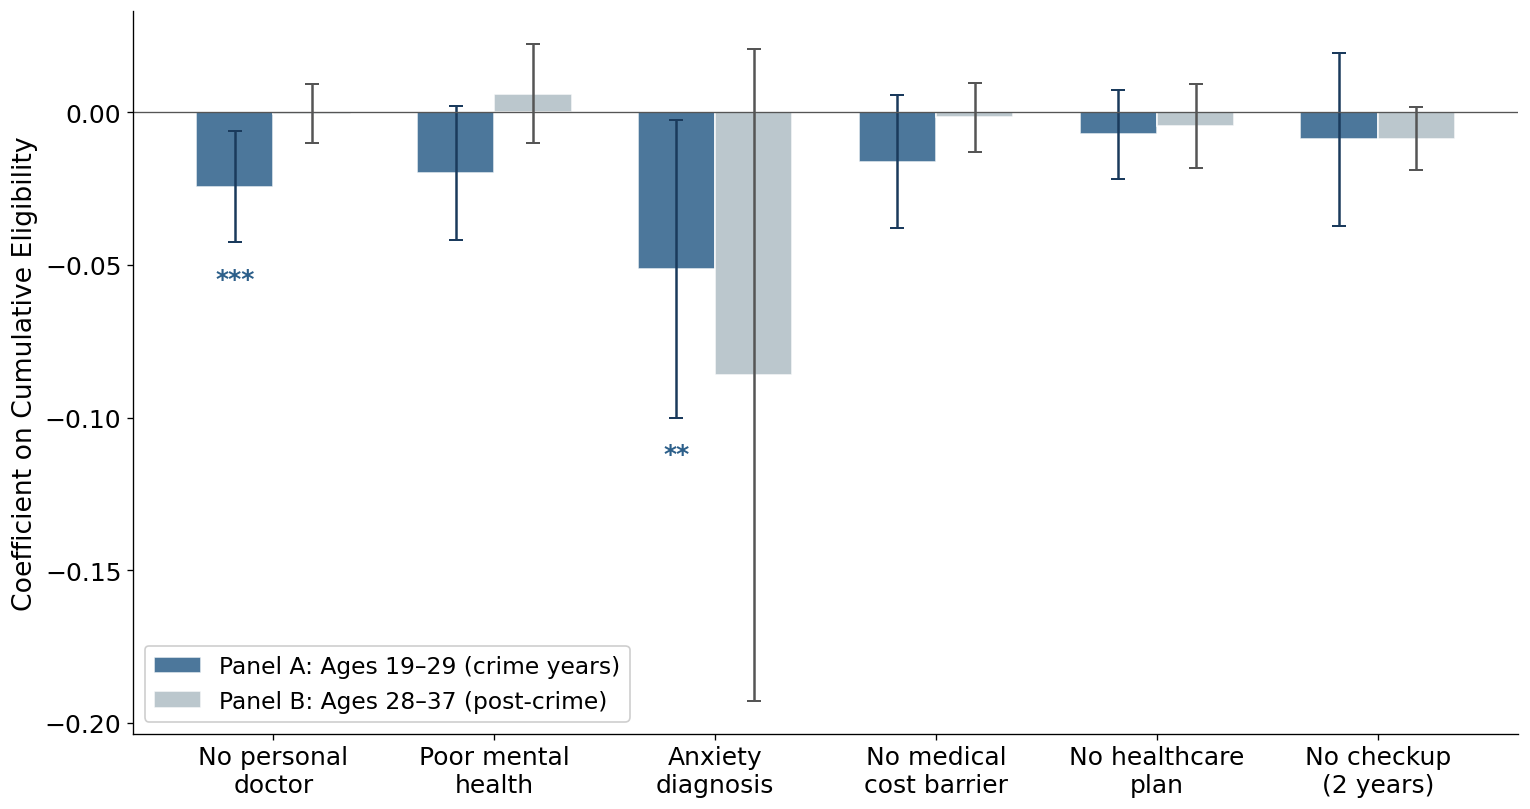

Saved: figure_12_brfss_panels.pdf / .png


In [ ]:
# ============================================================
# FIGURE 12: BRFSS Behavioral Health Outcomes —
#            Crime-Contemporaneous vs. Post-Crime Windows
# Thesis placement: Appendix F
# Caption handled in LaTeX — no title in the image
# ============================================================

# ---- Adjustable parameters ----
FIGSIZE             = (13, 7)
AXIS_LABEL_SIZE     = 16    # "Coefficient on Cumulative Eligibility"
TICK_SIZE           = 15    # x-axis outcome labels + y-axis numbers
LEGEND_SIZE         = 14
SIG_MARKER_SIZE     = 15    # "***", "**" significance stars

def figure_brfss_panels():
    outcomes = ["No personal\ndoctor", "Poor mental\nhealth", "Anxiety\ndiagnosis",
                "No medical\ncost barrier", "No healthcare\nplan", "No checkup\n(2 years)"]

    # Panel A: Ages 19–29 (crime years)
    panel_a     = [-0.0244, -0.0200, -0.0513, -0.0162, -0.0073, -0.0089]
    panel_a_se  = [ 0.0093,  0.0112,  0.0249,  0.0111,  0.0074,  0.0145]
    panel_a_sig = [3, 1, 2, 0, 0, 0]     # 0=ns, 1=10%, 2=5%, 3=1%

    # Panel B: Ages 28–37 (post-crime)
    panel_b     = [-0.0005,  0.0061, -0.0861, -0.0017, -0.0045, -0.0087]
    panel_b_se  = [ 0.0049,  0.0083,  0.0544,  0.0058,  0.0070,  0.0053]

    x = np.arange(len(outcomes))
    width = 0.35

    fig, ax = plt.subplots(figsize=FIGSIZE)

    # Panel A bars
    ax.bar(x - width/2, panel_a, width, color="#2C5F8A", alpha=0.85,
           label="Panel A: Ages 19–29 (crime years)", edgecolor="white")
    ax.errorbar(x - width/2, panel_a, yerr=[s*1.96 for s in panel_a_se],
                fmt="none", ecolor="#1a3a5c", capsize=4, capthick=1.2)

    # Panel B bars
    ax.bar(x + width/2, panel_b, width, color="#B0BEC5", alpha=0.85,
           label="Panel B: Ages 28–37 (post-crime)", edgecolor="white")
    ax.errorbar(x + width/2, panel_b, yerr=[s*1.96 for s in panel_b_se],
                fmt="none", ecolor="#555555", capsize=4, capthick=1.2)

    # Significance markers on Panel A bars
    for i in range(len(outcomes)):
        if panel_a_sig[i] >= 2:
            stars = "**" if panel_a_sig[i] == 2 else "***"
            y_pos = panel_a[i] - panel_a_se[i]*1.96 - 0.008
            ax.text(x[i] - width/2, y_pos, stars, ha="center", va="top",
                    fontsize=SIG_MARKER_SIZE, fontweight="bold", color="#2C5F8A")

    ax.axhline(y=0, color="#555555", linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(outcomes, fontsize=TICK_SIZE)
    ax.set_ylabel("Coefficient on Cumulative Eligibility", fontsize=AXIS_LABEL_SIZE)
    ax.tick_params(axis="y", labelsize=TICK_SIZE)
    ax.legend(fontsize=LEGEND_SIZE, loc="lower left", framealpha=0.95)
    ax.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    plt.savefig("figure_12_brfss_panels.pdf", bbox_inches="tight", dpi=300)
    plt.savefig("figure_12_brfss_panels.png", bbox_inches="tight", dpi=300)
    plt.show()
    print("Saved: figure_12_brfss_panels.pdf / .png")


figure_brfss_panels()

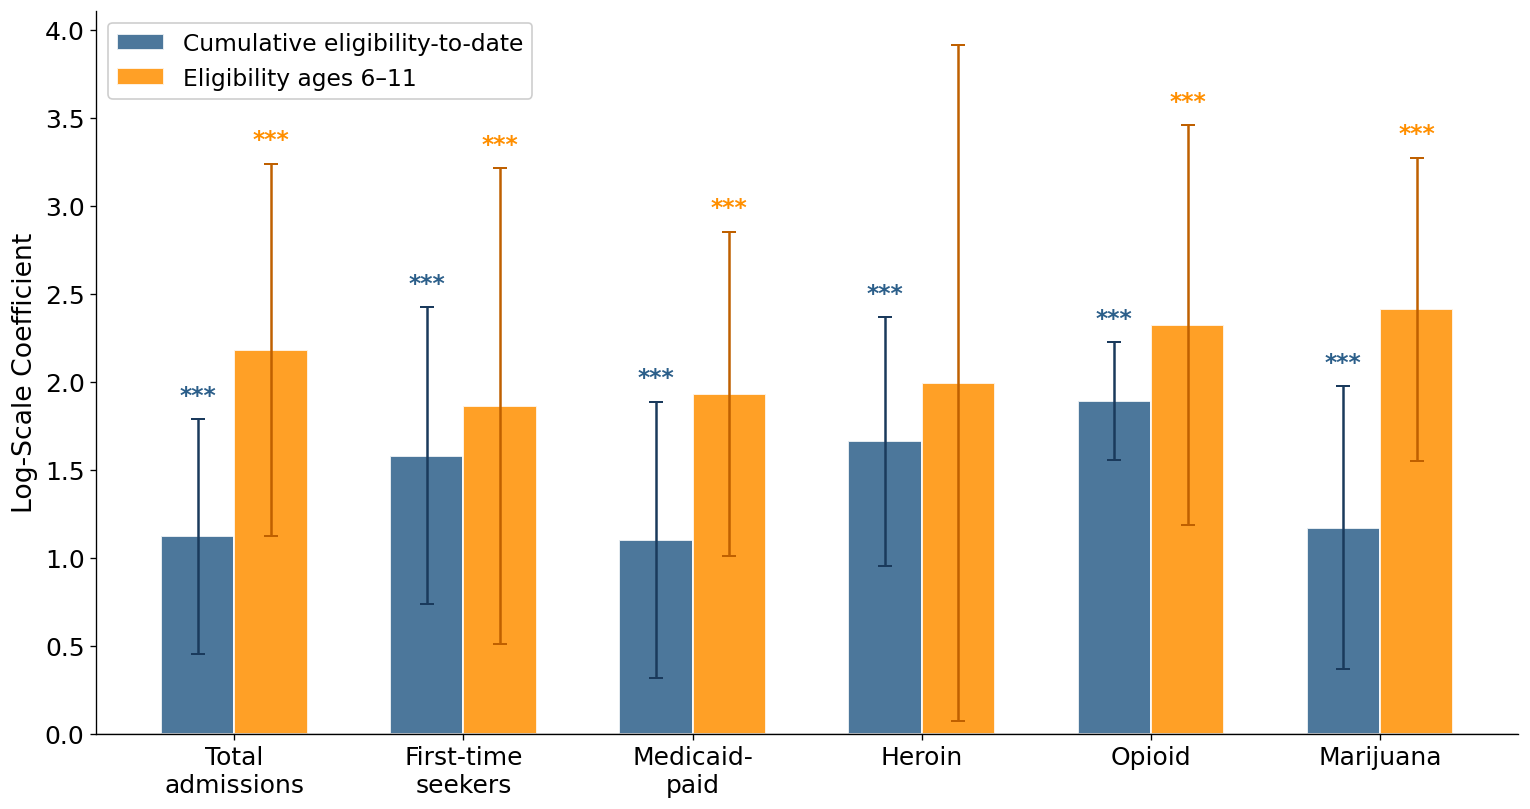

Saved: figure_13_tedsa_windows.pdf / .png


In [ ]:
# ============================================================
# FIGURE 13: TEDS-A Treatment Response by Eligibility Window
# Thesis placement: Appendix F
# Caption handled in LaTeX — no title in the image
# ============================================================

# ---- Adjustable parameters ----
FIGSIZE             = (13, 7)
AXIS_LABEL_SIZE     = 16    # "Log-Scale Coefficient"
TICK_SIZE           = 15    # x-axis outcome labels + y-axis numbers
LEGEND_SIZE         = 14
SIG_MARKER_SIZE     = 14    # "***" significance stars

def figure_tedsa_windows():
    outcomes = ["Total\nadmissions", "First-time\nseekers", "Medicaid-\npaid",
                "Heroin", "Opioid", "Marijuana"]
    cum_coefs  = [1.12, 1.58, 1.10, 1.66, 1.89, 1.17]
    cum_ses    = [0.34, 0.43, 0.40, 0.36, 0.17, 0.41]
    e611_coefs = [2.18, 1.86, 1.93, 1.99, 2.32, 2.41]
    e611_ses   = [0.54, 0.69, 0.47, 0.98, 0.58, 0.44]
    x = np.arange(len(outcomes))
    width = 0.32

    fig, ax = plt.subplots(figsize=FIGSIZE)
    ax.bar(x - width/2, cum_coefs,  width, color="#2C5F8A", alpha=0.85,
           edgecolor="white", linewidth=1.2, label="Cumulative eligibility-to-date")
    ax.bar(x + width/2, e611_coefs, width, color="#FF8F00", alpha=0.85,
           edgecolor="white", linewidth=1.2, label="Eligibility ages 6–11")
    ax.errorbar(x - width/2, cum_coefs,  yerr=[s*1.96 for s in cum_ses],
                fmt="none", ecolor="#1a3a5c", capsize=4, capthick=1.2)
    ax.errorbar(x + width/2, e611_coefs, yerr=[s*1.96 for s in e611_ses],
                fmt="none", ecolor="#BF6000", capsize=4, capthick=1.2)

    cum_sig  = ["***", "***", "***", "***", "***", "***"]
    e611_sig = ["***", "***", "***", "",    "***", "***"]
    for i in range(len(outcomes)):
        if cum_sig[i]:
            ax.text(x[i] - width/2, cum_coefs[i] + cum_ses[i]*1.96 + 0.1,
                    cum_sig[i], ha="center",
                    fontsize=SIG_MARKER_SIZE, fontweight="bold", color="#2C5F8A")
        if e611_sig[i]:
            ax.text(x[i] + width/2, e611_coefs[i] + e611_ses[i]*1.96 + 0.1,
                    e611_sig[i], ha="center",
                    fontsize=SIG_MARKER_SIZE, fontweight="bold", color="#FF8F00")

    ax.axhline(y=0, color="#555555", linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(outcomes, fontsize=TICK_SIZE)
    ax.set_ylabel("Log-Scale Coefficient", fontsize=AXIS_LABEL_SIZE)
    ax.tick_params(axis="y", labelsize=TICK_SIZE)
    ax.legend(fontsize=LEGEND_SIZE, loc="upper left", framealpha=0.95)
    ax.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    plt.savefig("figure_13_tedsa_windows.pdf", bbox_inches="tight", dpi=300)
    plt.savefig("figure_13_tedsa_windows.png", bbox_inches="tight", dpi=300)
    plt.show()
    print("Saved: figure_13_tedsa_windows.pdf / .png")


figure_tedsa_windows()

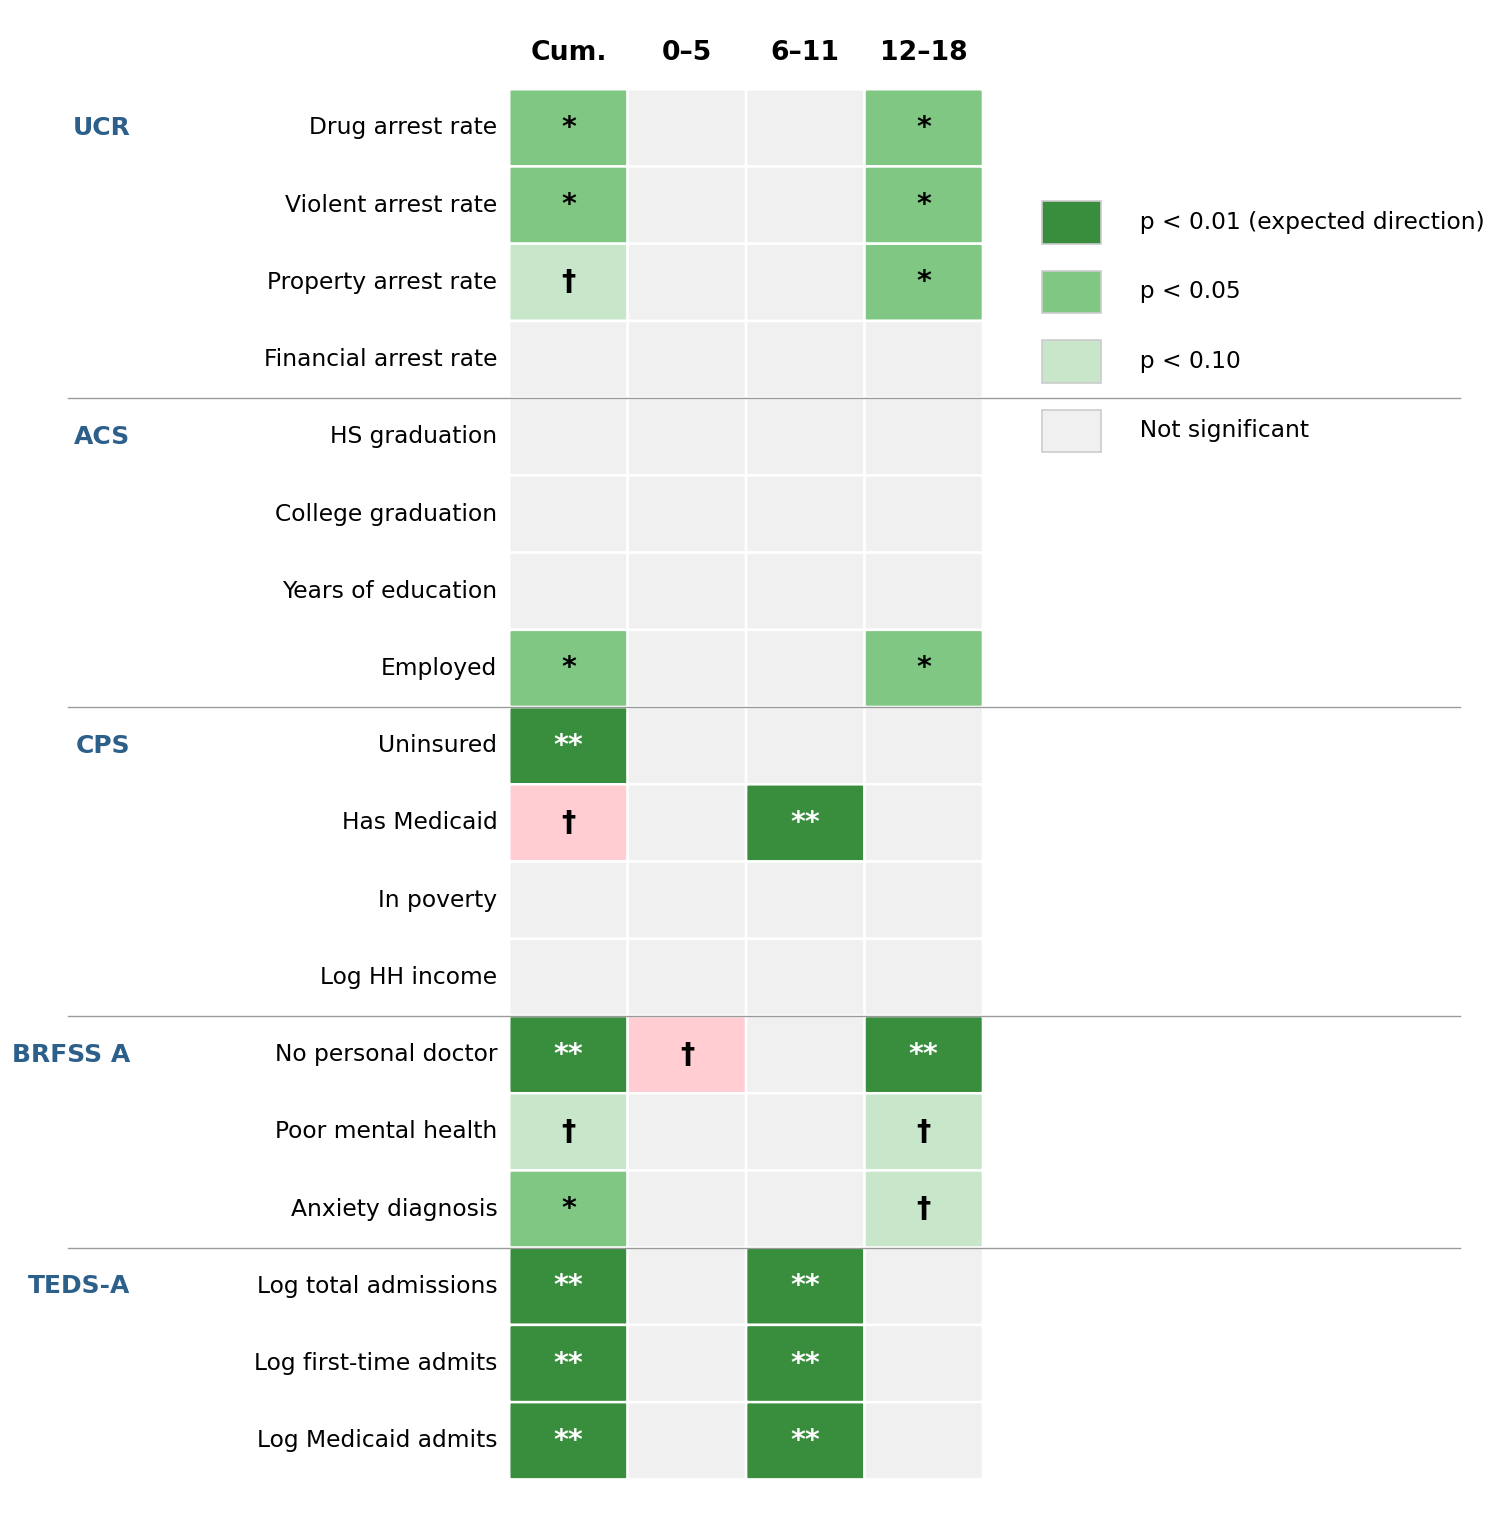

Saved: figure_14_mechanism_heatmap.pdf / .png


In [ ]:
# ============================================================
# FIGURE 14: Mechanism Significance Heatmap Across Datasets and Eligibility Windows
# Thesis placement: Appendix F (consider promoting to Section 6.1)
# Caption handled in LaTeX — no title in the image
# ============================================================

# ---- Adjustable parameters ----
FIGSIZE             = (13, 13)
ROW_LABEL_SIZE      = 14    # "Drug arrest rate", "HS graduation" etc.
COL_LABEL_SIZE      = 16    # "Cumulative", "Ages 0–5" column headers
GROUP_LABEL_SIZE    = 15    # "UCR", "ACS", "CPS" section labels on the left
SIG_STAR_SIZE       = 17    # "*", "**", "†" significance markers in cells
LEGEND_ITEM_SIZE    = 14    # text next to legend swatches

def figure_mechanism_heatmap():
    # (label, group, [coefs by window], [sig level 0-3])
    # sig: 0=ns, 1=p<.10 (†), 2=p<.05 (*), 3=p<.01 (**)
    data = [
        ("Drug arrest rate",         "UCR",      [-13.32, 34.78, -5.18, -16.55], [2, 0, 0, 2]),
        ("Violent arrest rate",      "UCR",      [-7.32, 7.06, -0.88, -9.20],    [2, 0, 0, 2]),
        ("Property arrest rate",     "UCR",      [-5.34, 5.81, 1.69, -7.62],     [1, 0, 0, 2]),
        ("Financial arrest rate",    "UCR",      [0.86, -31.66, -1.73, 3.37],    [0, 0, 0, 0]),
        ("HS graduation",            "ACS",      [-0.0017, 0.0006, -0.0015, -0.0016], [0, 0, 0, 0]),
        ("College graduation",       "ACS",      [0.0017, 0.0025, -0.0003, 0.0021],   [0, 0, 0, 0]),
        ("Years of education",       "ACS",      [-0.0088, 0.0353, 0.0008, -0.0128],  [0, 0, 0, 0]),
        ("Employed",                 "ACS",      [0.0054, 0.0049, -0.0003, 0.0065],   [2, 0, 0, 2]),
        ("Uninsured",                "CPS",      [-0.041, 0, 0, 0],                   [3, 0, 0, 0]),
        ("Has Medicaid",             "CPS",      [-0.007, -0.007, 0.023, -0.005],     [1, 0, 3, 0]),
        ("In poverty",               "CPS",      [0.002, -0.026, 0.007, 0.002],       [0, 0, 0, 0]),
        ("Log HH income",            "CPS",      [-0.015, 0.010, -0.019, 0.001],      [0, 0, 0, 0]),
        ("No personal doctor",       "BRFSS A",  [-0.0244, 0.0652, -0.0068, -0.0309], [3, 1, 0, 3]),
        ("Poor mental health",       "BRFSS A",  [-0.0200, 0.0149, -0.0098, -0.0209], [1, 0, 0, 1]),
        ("Anxiety diagnosis",        "BRFSS A",  [-0.0513, -0.1210, 0.0076, -0.0433], [2, 0, 0, 1]),
        ("Log total admissions",     "TEDS-A",   [1.12, 0, 2.18, 0],                  [3, 0, 3, 0]),
        ("Log first-time admits",    "TEDS-A",   [1.58, 0, 1.86, 0],                  [3, 0, 3, 0]),
        ("Log Medicaid admits",      "TEDS-A",   [1.10, 0, 1.93, 0],                  [3, 0, 3, 0]),
    ]
    n_rows, n_cols = len(data), 4
    windows = ["Cum.", "0–5", "6–11", "12–18"]
    positive_is_good = {"Has Medicaid", "Employed",
                        "Log total admissions", "Log first-time admits",
                        "Log Medicaid admits"}
    palette_good = {1: "#C8E6C9", 2: "#81C784", 3: "#388E3C"}
    palette_bad  = {1: "#FFCDD2", 2: "#EF9A9A", 3: "#E53935"}

    fig, ax = plt.subplots(figsize=FIGSIZE)

    # Cells
    for i, (label, group, coefs, sigs) in enumerate(data):
        for j in range(n_cols):
            sig = sigs[j]; coef = coefs[j]
            if sig == 0:
                color = "#F0F0F0"
            else:
                good = (coef < 0 and label not in positive_is_good) or \
                       (coef > 0 and label in positive_is_good)
                color = (palette_good if good else palette_bad)[sig]
            ax.add_patch(mpatches.FancyBboxPatch(
                (j + 0.02, n_rows - i - 1 + 0.02), 0.96, 0.96,
                boxstyle="round,pad=0.02",
                facecolor=color, edgecolor="white", linewidth=1.5))
            if sig > 0:
                stars = {1: "†", 2: "*", 3: "**"}[sig]
                text_color = "white" if sig == 3 else "black"
                ax.text(j + 0.5, n_rows - i - 0.5, stars,
                        ha="center", va="center",
                        fontsize=SIG_STAR_SIZE, fontweight="bold", color=text_color)

    # Row labels + group headers on the left
    current_group = None
    for i, (label, group, _, _) in enumerate(data):
        y = n_rows - i - 0.5
        ax.text(-0.1, y, label, ha="right", va="center",
                fontsize=ROW_LABEL_SIZE, color="black")
        if group != current_group:
            if current_group is not None:
                ax.axhline(y=n_rows - i, color="#999999", linewidth=0.8,
                           xmin=-0.02, xmax=1.02, clip_on=False)
            ax.text(-3.2, y, group, ha="right", va="center",
                    fontsize=GROUP_LABEL_SIZE, fontweight="bold", color="#2C5F8A")
            current_group = group

    # Column headers on top
    for j, w in enumerate(windows):
        ax.text(j + 0.5, n_rows + 0.3, w, ha="center", va="bottom",
                fontsize=COL_LABEL_SIZE, fontweight="bold", color="black")

    # Legend on the right
    legend_items = [
        ("#388E3C", "  p < 0.01 (expected direction)"),
        ("#81C784", "  p < 0.05"),
        ("#C8E6C9", "  p < 0.10"),
        ("#F0F0F0", "  Not significant"),
    ]
    for k, (color, desc) in enumerate(legend_items):
        ax.add_patch(mpatches.Rectangle(
            (n_cols + 0.5, n_rows - 2 - k*0.9), 0.5, 0.55,
            facecolor=color, edgecolor="#cccccc"))
        ax.text(n_cols + 1.2, n_rows - 1.72 - k*0.9, desc,
                va="center", fontsize=LEGEND_ITEM_SIZE, color="black")

    ax.set_xlim(-3.5, n_cols + 3.8)
    ax.set_ylim(-0.5, n_rows + 1)
    ax.axis("off")

    plt.tight_layout()
    plt.savefig("figure_14_mechanism_heatmap.pdf", bbox_inches="tight", dpi=300)
    plt.savefig("figure_14_mechanism_heatmap.png", bbox_inches="tight", dpi=300)
    plt.show()
    print("Saved: figure_14_mechanism_heatmap.pdf / .png")


figure_mechanism_heatmap()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

# Match the thesis's existing figure style - default matplotlib sans-serif
matplotlib.rcParams.update(matplotlib.rcParamsDefault)
matplotlib.rcParams['font.family'] = 'sans-serif'
matplotlib.rcParams['font.size'] = 11
matplotlib.rcParams['axes.labelsize'] = 13
matplotlib.rcParams['legend.fontsize'] = 9.5
matplotlib.rcParams['mathtext.fontset'] = 'dejavusans'

fig, ax = plt.subplots(1, 1, figsize=(7.5, 6))

L = np.linspace(0.15, 0.95, 300)

# --- MB_legal: U'(C^L) * w(K) ---
mb_legal_0 = 2.8 * (1 - L)**1.2 + 0.4
mb_legal_1 = 3.1 * (1 - L)**1.2 + 0.55

# --- MB_crime: Theta(M)^{-1} * S * E[U'(C^C)] * g'(1-L) ---
mb_crime_0 = 2.5 * L**1.3 + 0.3
mb_crime_1 = 1.8 * L**1.3 + 0.15

def find_intersection(y1, y2, x):
    diff = y1 - y2
    idx = np.where(np.diff(np.sign(diff)))[0][0]
    x1, x2 = x[idx], x[idx+1]
    d1, d2 = diff[idx], diff[idx+1]
    x_int = x1 - d1 * (x2 - x1) / (d2 - d1)
    y_int = np.interp(x_int, x, y1)
    return x_int, y_int

L_star_0, y_star_0 = find_intersection(mb_legal_0, mb_crime_0, L)
L_star_1, y_star_1 = find_intersection(mb_legal_1, mb_crime_1, L)

c_legal = '#2166AC'
c_crime = '#B2182B'

# Plot curves
ax.plot(L, mb_legal_0, color=c_legal, linewidth=2.2, label=r'MB$_{\mathrm{legal}}$ ($\Pi$=0)')
ax.plot(L, mb_crime_0, color=c_crime, linewidth=2.2, label=r'MB$_{\mathrm{crime}}$ ($\Pi$=0)')
ax.plot(L, mb_legal_1, color=c_legal, linewidth=2.2, linestyle='--', label=r'MB$_{\mathrm{legal}}$ ($\Pi$=1)')
ax.plot(L, mb_crime_1, color=c_crime, linewidth=2.2, linestyle='--', label=r'MB$_{\mathrm{crime}}$ ($\Pi$=1)')

# Equilibria
ax.plot(L_star_0, y_star_0, 'o', color='black', markersize=7, zorder=5)
ax.plot(L_star_1, y_star_1, 'o', color='black', markersize=7, zorder=5)

# Vertical lines
ax.plot([L_star_0, L_star_0], [0.15, y_star_0], ':', color='gray', linewidth=1.2)
ax.plot([L_star_1, L_star_1], [0.15, y_star_1], ':', color='gray', linewidth=1.2)

# L* labels as tick marks
ax.set_xticks([L_star_0, L_star_1])
ax.set_xticklabels([r'$L^*_{\Pi=0}$', r'$L^*_{\Pi=1}$'], fontsize=12)
ax.tick_params(axis='x', length=6, width=1.2)

# Human capital annotation - left side
idx_hc = 70
mid_x_hc = L[idx_hc]
ax.annotate('', xy=(mid_x_hc, mb_legal_1[idx_hc] - 0.03),
            xytext=(mid_x_hc, mb_legal_0[idx_hc] + 0.03),
            arrowprops=dict(arrowstyle='->', color=c_legal, lw=1.8))
ax.text(mid_x_hc + 0.03, (mb_legal_0[idx_hc] + mb_legal_1[idx_hc])/2,
        r'$\uparrow w(K)$' + '\nHuman Capital',
        fontsize=9, color=c_legal, ha='left', va='center',
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='none', alpha=0.8))

# Behavioral health + Financial stability - right side
idx_bh = 240
mid_x_bh = L[idx_bh]
ax.annotate('', xy=(mid_x_bh, mb_crime_1[idx_bh] + 0.03),
            xytext=(mid_x_bh, mb_crime_0[idx_bh] - 0.03),
            arrowprops=dict(arrowstyle='->', color=c_crime, lw=1.8))
ax.text(mid_x_bh - 0.03, (mb_crime_0[idx_bh] + mb_crime_1[idx_bh])/2 + 0.05,
        r'$\uparrow \Theta,\ \uparrow \beta,\ \downarrow S$' + '\nBehavioral Health\n& Financial Stability',
        fontsize=8.5, color=c_crime, ha='right', va='center',
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='none', alpha=0.8))

# Delta L* arrow
arrow_y = min(y_star_0, y_star_1) - 0.5
ax.annotate('', xy=(L_star_1 - 0.01, arrow_y),
            xytext=(L_star_0 + 0.01, arrow_y),
            arrowprops=dict(arrowstyle='->', color='black', lw=2))
ax.text((L_star_0 + L_star_1)/2, arrow_y - 0.2, r'$\Delta L^*$',
        ha='center', fontsize=13, fontweight='bold')

# Axes
ax.set_xlabel(r'$L$ (Legal Time Share)', fontsize=13, labelpad=10)
ax.set_ylabel('Marginal Utility', fontsize=13)
ax.set_xlim(0.15, 0.95)
ax.set_ylim(0, 3.5)
ax.set_yticks([])

# Legend
ax.legend(loc='upper right', fontsize=9.5, framealpha=0.95, edgecolor='gray')

# Spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)

plt.tight_layout()
plt.savefig('/home/claude/comparative_statics_final.pdf', bbox_inches='tight', dpi=300)
plt.savefig('/home/claude/comparative_statics_final.png', bbox_inches='tight', dpi=300)
print("Done")

FileNotFoundError: [Errno 2] No such file or directory: '/home/claude/comparative_statics_final.pdf'